In [2]:
from cobra.io import read_sbml_model
import requests
import os
import pandas as pd

In [3]:
ecoli = read_sbml_model('iML1515.xml')
#ecoli.summary()

In [4]:
from cobra.io import read_sbml_model

ecoli_model = read_sbml_model('iML1515.xml')

In [5]:
print(ecoli_model.medium)

{'EX_pi_e': 1000.0, 'EX_co2_e': 1000.0, 'EX_fe3_e': 1000.0, 'EX_h_e': 1000.0, 'EX_mn2_e': 1000.0, 'EX_fe2_e': 1000.0, 'EX_glc__D_e': 10.0, 'EX_zn2_e': 1000.0, 'EX_mg2_e': 1000.0, 'EX_ca2_e': 1000.0, 'EX_ni2_e': 1000.0, 'EX_cu2_e': 1000.0, 'EX_sel_e': 1000.0, 'EX_cobalt2_e': 1000.0, 'EX_h2o_e': 1000.0, 'EX_mobd_e': 1000.0, 'EX_so4_e': 1000.0, 'EX_nh4_e': 1000.0, 'EX_k_e': 1000.0, 'EX_na1_e': 1000.0, 'EX_cl_e': 1000.0, 'EX_o2_e': 1000.0, 'EX_tungs_e': 1000.0, 'EX_slnt_e': 1000.0}


In [6]:
#Target genes
genes = [
    "c-di-gmp", "dgcE", "ydaM",
    "cpsG", "wcaJ",
    "luxS", "lsrA", "lsrB", "lsrC", "lsrD", "lsrK", "lsrR",
    "rpoS",
    "bcsA", "csgA",
    "csrA", "yahA", "gmr", "bcsZ", "pgaB"
]


gene_map = {}
for gene in ecoli_model.genes:
				gen = ecoli_model.genes.get_by_id(gene.id)
				for eps	in genes:
					if eps in gen.name:
						gene_map[gen.id] = {
							"gene_name": gen.name,
							"reactions": [rxn.id for rxn in gen.reactions],
							"metabolites": [met.id for rxn in gen.reactions for met in rxn.metabolites]
						}

print(gene_map)

{'b2687': {'gene_name': 'luxS', 'reactions': ['RHCCE'], 'metabolites': ['rhcys_c', 'dhptd_c', 'hcys__L_c']}, 'b2048': {'gene_name': 'cpsG', 'reactions': ['PMANM'], 'metabolites': ['man1p_c', 'man6p_c']}, 'b1511': {'gene_name': 'lsrK', 'reactions': ['AI2K'], 'metabolites': ['atp_c', 'dhptd_c', 'adp_c', 'dhptdp_c', 'h_c']}, 'b1516': {'gene_name': 'lsrB', 'reactions': ['AI2abcpp'], 'metabolites': ['atp_c', 'h2o_c', 'mththf_p', 'adp_c', 'h_c', 'mththf_c', 'pi_c']}, 'b1513': {'gene_name': 'lsrA', 'reactions': ['AI2abcpp'], 'metabolites': ['atp_c', 'h2o_c', 'mththf_p', 'adp_c', 'h_c', 'mththf_c', 'pi_c']}, 'b1514': {'gene_name': 'lsrC', 'reactions': ['AI2abcpp'], 'metabolites': ['atp_c', 'h2o_c', 'mththf_p', 'adp_c', 'h_c', 'mththf_c', 'pi_c']}, 'b1515': {'gene_name': 'lsrD', 'reactions': ['AI2abcpp'], 'metabolites': ['atp_c', 'h2o_c', 'mththf_p', 'adp_c', 'h_c', 'mththf_c', 'pi_c']}, 'b2047': {'gene_name': 'wcaJ', 'reactions': ['UDPGPT'], 'metabolites': ['udcpp_c', 'udpg_c', 'udcpgl_c', 'um

In [7]:
for reaction in ecoli_model.reactions:
				if "biomass" in reaction.name:
					print(reaction.id, reaction.name)

BIOMASS_Ec_iML1515_core_75p37M E. coli biomass objective function (iML1515) - core - with 75.37 GAM estimate
BIOMASS_Ec_iML1515_WT_75p37M E. coli biomass objective function (iML1515) - WT - with 75.37 GAM estimate


In [8]:
#doesn't produce anything, just need the functions like def_set_medium()

from cobra.io import read_sbml_model
from cobra.flux_analysis import pfba
import pandas as pd

model = ecoli_model.copy()

# -------------------------
# 1. Define M9 medium
# -------------------------
def set_m9_glucose_medium(model,
                          glucose_uptake=10.0,
                          oxygen_uptake=20.0,
                          ammonium_uptake=10.0,
                          phosphate_uptake=10.0,
                          sulfate_uptake=10.0):
    # close all exchanges first
    for rxn in model.exchanges:
        rxn.lower_bound = 0.0

    # open standard M9 components
    medium_bounds = {
        "EX_glc__D_e": -glucose_uptake,
        "EX_o2_e": -oxygen_uptake,
        "EX_nh4_e": -ammonium_uptake,
        "EX_pi_e": -phosphate_uptake,
        "EX_so4_e": -sulfate_uptake,
        "EX_h2o_e": -1000.0,
        "EX_h_e": -1000.0,
        "EX_na1_e": -1000.0,
        "EX_k_e": -1000.0,
        "EX_mg2_e": -1000.0,
        "EX_ca2_e": -1000.0,
        "EX_cl_e": -1000.0,
        "EX_fe2_e": -1000.0
    }

    for rxn_id, lb in medium_bounds.items():
        if rxn_id in model.reactions:
            model.reactions.get_by_id(rxn_id).lower_bound = lb

# -------------------------
# 2. Flux readout helper
# -------------------------
tracked_rxns = [
    "BIOMASS_Ec_iML1515_core_75p37M",  # replace if needed
    "PMANM",
    "UDPGPT",
    "DGUNC",
    "CDGUNPD",
    "LDGUNPD",
    "RHCCE",
    "AI2abcpp",
    "AI2K"
]

def collect_fluxes(solution, rxn_ids):
    out = {}
    for rid in rxn_ids:
        out[rid] = solution.fluxes[rid] if rid in solution.fluxes.index else None
    return out

# -------------------------
# 3. EPS optimization
# -------------------------
def optimize_eps_proxy(model, biomass_rxn_id, eps_rxn_id="UDPGPT", frac=0.9):
    # maximize biomass first
    model.objective = biomass_rxn_id
    sol_growth = model.optimize()
    mu_max = sol_growth.objective_value

    # constrain biomass
    biomass_rxn = model.reactions.get_by_id(biomass_rxn_id)
    old_lb = biomass_rxn.lower_bound
    biomass_rxn.lower_bound = frac * mu_max

    # maximize EPS proxy
    model.objective = eps_rxn_id
    sol_eps = model.optimize()

    # reset
    biomass_rxn.lower_bound = old_lb

    return mu_max, sol_growth, sol_eps

# -------------------------
# 4. Run conditions
# -------------------------
results = []

conditions = {
    "baseline_M9": {"glucose": 10, "oxygen": 20, "nh4": 10, "knockdown_cdg_deg": False},
    "high_glucose": {"glucose": 20, "oxygen": 20, "nh4": 10, "knockdown_cdg_deg": False},
    "N_limited": {"glucose": 10, "oxygen": 20, "nh4": 2, "knockdown_cdg_deg": False},
    "high_cdiGMP": {"glucose": 10, "oxygen": 20, "nh4": 10, "knockdown_cdg_deg": True},
    "combined_eps_state": {"glucose": 20, "oxygen": 20, "nh4": 2, "knockdown_cdg_deg": True},
}

biomass_rxn_id = "BIOMASS_Ec_iML1515_core_75p37M"  
for cond_name, pars in conditions.items():
    m = ecoli_model.copy()

    set_m9_glucose_medium(
        m,
        glucose_uptake=pars["glucose"],
        oxygen_uptake=pars["oxygen"],
        ammonium_uptake=pars["nh4"]
    )

    if pars["knockdown_cdg_deg"]:
        for rid in ["CDGUNPD", "LDGUNPD"]:
            if rid in m.reactions:
                rxn = m.reactions.get_by_id(rid)
                rxn.upper_bound = 0.0
                rxn.lower_bound = 0.0

    # pFBA under biomass objective
    m.objective = biomass_rxn_id
    sol = pfba(m)

    row = {"condition": cond_name}
    row.update(collect_fluxes(sol, tracked_rxns))

    # biomass-constrained EPS optimization
    mu_max, sol_growth, sol_eps = optimize_eps_proxy(m, biomass_rxn_id, eps_rxn_id="UDPGPT", frac=0.9)
    row["mu_max"] = mu_max
    row["eps_opt_UDPGPT"] = sol_eps.fluxes["UDPGPT"] if "UDPGPT" in sol_eps.fluxes.index else None
    row["eps_opt_PMANM"] = sol_eps.fluxes["PMANM"] if "PMANM" in sol_eps.fluxes.index else None

    results.append(row)

df = pd.DataFrame(results)
print(df)

            condition  BIOMASS_Ec_iML1515_core_75p37M  PMANM  UDPGPT  DGUNC  \
0         baseline_M9                             0.0    0.0     0.0    0.0   
1        high_glucose                             0.0    0.0     0.0    0.0   
2           N_limited                             0.0    0.0     0.0    0.0   
3         high_cdiGMP                             0.0    0.0     0.0    0.0   
4  combined_eps_state                             0.0    0.0     0.0    0.0   

   CDGUNPD  LDGUNPD         RHCCE  AI2abcpp          AI2K        mu_max  \
0      0.0      0.0 -4.342239e-18       0.0  4.220166e-32  0.000000e+00   
1      0.0      0.0 -4.342239e-18       0.0  4.220166e-32  0.000000e+00   
2      0.0      0.0 -4.342239e-18       0.0  4.220166e-32  0.000000e+00   
3      0.0      0.0  0.000000e+00       0.0  0.000000e+00 -7.221096e-31   
4      0.0      0.0  0.000000e+00       0.0  0.000000e+00 -7.221096e-31   

   eps_opt_UDPGPT  eps_opt_PMANM  
0             0.0            0.0  
1   

In [9]:
"""

eps_experiment_iML1515_gene_map.py

Full EPS-related in silico experiment in an E. coli GSMM
using a gene_map-driven reaction tracking workflow.

What this script does
---------------------
1. Loads an E. coli SBML model (for example iML1515)
2. Uses the model's existing working medium as the baseline
3. Builds a gene_map for EPS/biofilm-related genes:
      gene_id -> gene_name -> reactions -> metabolites
4. Derives tracked reactions directly from gene_map
5. Runs several environmental / regulatory perturbations:
      - baseline
      - high_glucose
      - low_oxygen
      - N_limited
      - high_cdiGMP
      - combined_eps_state
6. For each condition:
      - runs pFBA under biomass objective
      - records fluxes of all tracked reactions
7. Then performs biomass-constrained EPS optimization:
      - maximize biomass
      - constrain biomass to 90% of max
      - maximize UDPGPT (EPS proxy)
8. Saves:
      - full results CSV
      - compact summary CSV
      - gene_map CSV
      - gene_map JSON
      - bar plots

Main biological interpretation
------------------------------
- Strong EPS proxy: UDPGPT (wcaJ-associated)
- Supporting precursor: PMANM (cpsG-associated)
- c-di-GMP regulation: DGUNC, CDGUNPD, LDGUNPD
- AI-2 / quorum sensing branch: RHCCE, AI2abcpp, AI2K

Dependencies
------------
pip install cobra pandas matplotlib

Usage
-----
Edit MODEL_PATH and OUTPUT_DIR, then run:
python eps_experiment_iML1515_gene_map.py
"""

from __future__ import annotations

import json
import warnings
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from cobra.io import read_sbml_model
from cobra.flux_analysis import pfba


# ============================================================
# USER SETTINGS
# ============================================================

MODEL_PATH = "iML1515.xml"
OUTPUT_DIR = "/Users/mayaabdalla/Downloads/output"

# If None, auto-detect from model
BIOMASS_RXN_ID = None

# EPS proxy objective for second-stage optimization
EPS_PROXY_RXN_ID = "UDPGPT"

# Maintain this fraction of max biomass during EPS optimization
BIOMASS_FRACTION_FOR_EPS = 0.90

# Gene keywords / targets used to build gene_map
EPS_GENES = [
    "c-di-gmp", "dgcE", "ydaM",
    "cpsG", "wcaJ",
    "luxS", "lsrA", "lsrB", "lsrC", "lsrD", "lsrK", "lsrR",
    "rpoS",
    "bcsA", "csgA",
    "csrA", "yahA", "gmr", "bcsZ", "pgaB"
]


# ============================================================
# GENERAL HELPERS
# ============================================================

def ensure_dir(path: str | Path) -> Path:
    p = Path(path)
    p.mkdir(parents=True, exist_ok=True)
    return p


def safe_float(x):
    try:
        if x is None:
            return None
        val = float(x)
        if abs(val) < 1e-12:
            return 0.0
        return val
    except Exception:
        return None


def dedupe_keep_order(items):
    seen = set()
    out = []
    for item in items:
        if item not in seen:
            out.append(item)
            seen.add(item)
    return out


# ============================================================
# MODEL / REACTION HELPERS
# ============================================================

def print_candidate_biomass_reactions(model):
    print("\nCandidate biomass reactions:")
    found = False
    for rxn in model.reactions:
        rid = rxn.id.lower()
        rname = (rxn.name or "").lower()
        if "biomass" in rid or "biomass" in rname:
            print(f"  {rxn.id} | {rxn.name}")
            found = True
    if not found:
        print("  None found")


def find_biomass_reaction(model) -> str:
    candidates = []
    for rxn in model.reactions:
        rid = rxn.id.lower()
        rname = (rxn.name or "").lower()
        if "biomass" in rid or "biomass" in rname:
            candidates.append(rxn)

    if not candidates:
        raise ValueError("No biomass reaction found in model.")

    scored = []
    for rxn in candidates:
        score = 0
        rid = rxn.id.lower()
        rname = (rxn.name or "").lower()

        if "iml1515" in rid or "iml1515" in rname:
            score += 5
        if "ec" in rid or "coli" in rid or "escherichia" in rname:
            score += 2
        if "core" in rid or "core" in rname:
            score += 1

        scored.append((score, rxn.id, rxn))

    scored.sort(key=lambda x: (x[0], x[1]), reverse=True)
    return scored[0][2].id


def verify_reactions_exist(model, rxn_ids):
    existing = {r.id for r in model.reactions}
    present = [rid for rid in rxn_ids if rid in existing]
    missing = [rid for rid in rxn_ids if rid not in existing]
    return present, missing


def knockout_reactions(model, rxn_ids):
    for rid in rxn_ids:
        if rid in model.reactions:
            rxn = model.reactions.get_by_id(rid)
            rxn.lower_bound = 0.0
            rxn.upper_bound = 0.0


def get_flux(solution, rxn_id):
    if solution is None:
        return None
    if not hasattr(solution, "fluxes"):
        return None
    if rxn_id not in solution.fluxes.index:
        return None
    return safe_float(solution.fluxes[rxn_id])


def collect_fluxes(solution, rxn_ids):
    out = {}
    for rid in rxn_ids:
        out[rid] = get_flux(solution, rid)
    return out


# ============================================================
# GENE MAP HELPERS
# ============================================================

def classify_gene_role(gene_id: str, gene_name: str) -> str:
    gid = (gene_id or "").lower()
    gname = (gene_name or "").lower()

    token = gid if gid else gname

    if token in {"wcaj", "cpsg", "bcsa", "bcsz", "pgab"} or gname in {"wcaj", "cpsg", "bcsa", "bcsz", "pgab"}:
        return "EPS_structure_or_precursor"

    if token in {"ydam", "yaha", "gmr"} or gname in {"ydam", "yaha", "gmr"}:
        return "c-di-GMP_regulation"

    if token in {"luxs", "lsra", "lsrb", "lsrc", "lsrd", "lsrk", "lsrr"} or gname in {
        "luxs", "lsra", "lsrb", "lsrc", "lsrd", "lsrk", "lsrr"
    }:
        return "quorum_sensing"

    if token in {"rpos", "csra", "csga"} or gname in {"rpos", "csra", "csga"}:
        return "regulatory_or_matrix_associated"

    return "other"


def build_gene_map(model, eps_genes):
    """
    Build:
    gene_map[gene_id] = {
        "gene_name": ...,
        "matched_keyword": ...,
        "role": ...,
        "reactions": [...],
        "metabolites": [...]
    }
    """
    gene_map = {}
    eps_genes_lower = [g.lower() for g in eps_genes]

    for gene in model.genes:
        gen = model.genes.get_by_id(gene.id)
        gene_id = gen.id
        gene_id_lower = gene_id.lower()
        gene_name = gen.name or ""
        gene_name_lower = gene_name.lower()

        matched_keyword = None

        # exact gene id match first
        for eps in eps_genes_lower:
            if gene_id_lower == eps:
                matched_keyword = eps
                break

        # exact gene name match next
        if matched_keyword is None:
            for eps in eps_genes_lower:
                if gene_name_lower == eps:
                    matched_keyword = eps
                    break

        # substring fallback
        if matched_keyword is None:
            for eps in eps_genes_lower:
                if eps and eps in gene_name_lower:
                    matched_keyword = eps
                    break

        if matched_keyword is None:
            continue

        reactions = list(gen.reactions)
        reaction_ids = [rxn.id for rxn in reactions]
        metabolites = sorted({
            met.id
            for rxn in reactions
            for met in rxn.metabolites
        })

        gene_map[gene_id] = {
            "gene_name": gene_name,
            "matched_keyword": matched_keyword,
            "role": classify_gene_role(gene_id_lower, gene_name_lower),
            "reactions": reaction_ids,
            "metabolites": metabolites
        }

    return gene_map


def get_tracked_reactions_from_gene_map(gene_map, biomass_rxn_id=None):
    rxns = []
    if biomass_rxn_id is not None:
        rxns.append(biomass_rxn_id)

    for info in gene_map.values():
        rxns.extend(info["reactions"])

    return dedupe_keep_order(rxns)


def gene_map_to_dataframe(gene_map):
    rows = []
    for gene_id, info in gene_map.items():
        reactions = info.get("reactions", [])
        metabolites = info.get("metabolites", [])

        if reactions:
            for rxn in reactions:
                rows.append({
                    "gene_id": gene_id,
                    "gene_name": info.get("gene_name"),
                    "matched_keyword": info.get("matched_keyword"),
                    "role": info.get("role"),
                    "reaction_id": rxn,
                    "metabolites": ";".join(metabolites)
                })
        else:
            rows.append({
                "gene_id": gene_id,
                "gene_name": info.get("gene_name"),
                "matched_keyword": info.get("matched_keyword"),
                "role": info.get("role"),
                "reaction_id": None,
                "metabolites": ";".join(metabolites)
            })

    return pd.DataFrame(rows)


# ============================================================
# EXPERIMENT HELPERS
# ============================================================

def run_pfba_condition(model, biomass_rxn_id, tracked_rxns):
    model.objective = biomass_rxn_id
    try:
        sol = pfba(model)
    except Exception as e:
        warnings.warn(f"pFBA failed: {e}")
        return None, {
            "status": "pfba_failed",
            "growth": None,
            **{rid: None for rid in tracked_rxns}
        }

    row = {
        "status": getattr(sol, "status", "unknown"),
        "growth": get_flux(sol, biomass_rxn_id)
    }
    row.update(collect_fluxes(sol, tracked_rxns))
    return sol, row


def maximize_eps_given_growth(model, biomass_rxn_id, eps_rxn_id, tracked_rxns, frac=0.90):
    """
    Step 1: maximize biomass
    Step 2: constrain biomass >= frac * mu_max
    Step 3: maximize eps_rxn_id
    """
    m = model.copy()
    m.objective = biomass_rxn_id

    try:
        sol_growth = m.optimize()
    except Exception as e:
        warnings.warn(f"Growth optimization failed: {e}")
        return {
            "mu_max": None,
            "eps_opt_status": "growth_optimization_failed",
            "eps_opt_growth": None,
            "eps_opt_objective": None,
            **{f"eps_opt_{rid}": None for rid in tracked_rxns}
        }

    mu_max = safe_float(sol_growth.objective_value)

    if mu_max is None or mu_max <= 1e-12:
        return {
            "mu_max": 0.0 if mu_max is not None else None,
            "eps_opt_status": "no_growth",
            "eps_opt_growth": 0.0 if mu_max is not None else None,
            "eps_opt_objective": 0.0,
            **{f"eps_opt_{rid}": 0.0 for rid in tracked_rxns}
        }

    if eps_rxn_id not in m.reactions:
        return {
            "mu_max": mu_max,
            "eps_opt_status": f"missing_eps_reaction_{eps_rxn_id}",
            "eps_opt_growth": None,
            "eps_opt_objective": None,
            **{f"eps_opt_{rid}": None for rid in tracked_rxns}
        }

    biomass_rxn = m.reactions.get_by_id(biomass_rxn_id)
    old_lb = biomass_rxn.lower_bound

    try:
        biomass_rxn.lower_bound = frac * mu_max
        m.objective = eps_rxn_id
        sol_eps = m.optimize()

        row = {
            "mu_max": mu_max,
            "eps_opt_status": getattr(sol_eps, "status", "unknown"),
            "eps_opt_growth": get_flux(sol_eps, biomass_rxn_id),
            "eps_opt_objective": safe_float(sol_eps.objective_value)
        }

        for rid in tracked_rxns:
            row[f"eps_opt_{rid}"] = get_flux(sol_eps, rid)

    except Exception as e:
        warnings.warn(f"EPS optimization failed: {e}")
        row = {
            "mu_max": mu_max,
            "eps_opt_status": "eps_optimization_failed",
            "eps_opt_growth": None,
            "eps_opt_objective": None,
            **{f"eps_opt_{rid}": None for rid in tracked_rxns}
        }
    finally:
        biomass_rxn.lower_bound = old_lb

    return row


def build_eps_score(row):
    """
    Heuristic EPS-associated score.
    Weights emphasize EPS initiation first, then precursor/regulatory support.
    """
    udpgpt = safe_float(row.get("eps_opt_UDPGPT")) or 0.0
    pmanm = safe_float(row.get("eps_opt_PMANM")) or 0.0
    dgunc = safe_float(row.get("eps_opt_DGUNC")) or 0.0
    cdgunpd = safe_float(row.get("eps_opt_CDGUNPD")) or 0.0
    ldgunpd = safe_float(row.get("eps_opt_LDGUNPD")) or 0.0
    ai2k = safe_float(row.get("eps_opt_AI2K")) or 0.0
    rhcce = safe_float(row.get("eps_opt_RHCCE")) or 0.0

    score = (
        3.0 * udpgpt +
        1.5 * pmanm +
        1.0 * dgunc +
        0.5 * ai2k +
        0.25 * rhcce -
        1.0 * cdgunpd -
        1.0 * ldgunpd
    )
    return score


def build_dynamic_preferred_cols(df, tracked_rxns):
    cols = [
        "condition",
        "glucose_uptake",
        "oxygen_uptake",
        "ammonium_uptake",
        "phosphate_uptake",
        "sulfate_uptake",
        "knockouts",
        "status",
        "growth",
        "mu_max",
        "eps_opt_status",
        "eps_opt_growth",
        "eps_opt_objective",
        "eps_score",
    ]

    for rid in tracked_rxns:
        if rid in df.columns:
            cols.append(rid)

    for rid in tracked_rxns:
        eps_col = f"eps_opt_{rid}"
        if eps_col in df.columns:
            cols.append(eps_col)

    return dedupe_keep_order(cols)


def save_barplot(df, xcol, ycol, outpath, title=None):
    plot_df = df[[xcol, ycol]].copy().dropna()
    if plot_df.empty:
        return

    plt.figure(figsize=(10, 5))
    plt.bar(plot_df[xcol], plot_df[ycol])
    plt.xticks(rotation=30, ha="right")
    plt.ylabel(ycol)
    if title:
        plt.title(title)
    plt.tight_layout()
    plt.savefig(outpath, dpi=200)
    plt.close()


# ============================================================
# MAIN
# ============================================================

def main():
    outdir = ensure_dir(OUTPUT_DIR)

    print(f"Loading model from: {MODEL_PATH}")
    model = read_sbml_model(MODEL_PATH)

    print_candidate_biomass_reactions(model)

    biomass_rxn_id = BIOMASS_RXN_ID or find_biomass_reaction(model)
    print(f"\nUsing biomass reaction: {biomass_rxn_id}")

    base_growth = safe_float(model.slim_optimize())
    print(f"Default model growth before any perturbation: {base_growth}")

    print("\nBaseline model medium:")
    for k, v in sorted(model.medium.items()):
        print(f"  {k}: {v}")

    # --------------------------------------------------------
    # Build gene_map
    # --------------------------------------------------------
    gene_map = build_gene_map(model, EPS_GENES)

    print("\nGene map:")
    if gene_map:
        for gid, info in gene_map.items():
            print(
                f"  {gid} | {info['gene_name']} | "
                f"matched={info['matched_keyword']} | "
                f"role={info['role']} | "
                f"reactions={info['reactions']} | "
                f"metabolites={info['metabolites']}"
            )
    else:
        print("  No matching genes found.")

    # save gene_map as JSON
    gene_map_json_path = outdir / "gene_map.json"
    with open(gene_map_json_path, "w") as f:
        json.dump(gene_map, f, indent=2)
    print(f"\nSaved gene_map JSON to: {gene_map_json_path}")

    # save gene_map as CSV
    gene_map_df = gene_map_to_dataframe(gene_map)
    gene_map_csv_path = outdir / "gene_map.csv"
    gene_map_df.to_csv(gene_map_csv_path, index=False)
    print(f"Saved gene_map CSV to: {gene_map_csv_path}")

    # --------------------------------------------------------
    # Derive tracked reactions from gene_map
    # --------------------------------------------------------
    tracked_rxns = get_tracked_reactions_from_gene_map(
        gene_map,
        biomass_rxn_id=biomass_rxn_id
    )

    print("\nTracked reactions derived from gene_map:")
    for rid in tracked_rxns:
        print(f"  {rid}")

    present, missing = verify_reactions_exist(model, tracked_rxns)
    print("\nTracked reactions present in model:")
    for rid in present:
        print(f"  {rid}")

    if missing:
        print("\nTracked reactions missing from model:")
        for rid in missing:
            print(f"  {rid}")

    # --------------------------------------------------------
    # Experimental conditions
    # --------------------------------------------------------
    base_medium = model.medium.copy()

    conditions = {
        "baseline": {
            "medium_changes": {},
            "knockout_rxns": []
        },
        "high_glucose": {
            "medium_changes": {"EX_glc__D_e": 20.0},
            "knockout_rxns": []
        },
        "low_oxygen": {
            "medium_changes": {"EX_o2_e": 5.0},
            "knockout_rxns": []
        },
        "N_limited": {
            "medium_changes": {"EX_nh4_e": 2.0},
            "knockout_rxns": []
        },
        "high_cdiGMP": {
            "medium_changes": {},
            "knockout_rxns": ["CDGUNPD", "LDGUNPD"]
        },
        "combined_eps_state": {
            "medium_changes": {"EX_glc__D_e": 20.0, "EX_nh4_e": 2.0},
            "knockout_rxns": ["CDGUNPD", "LDGUNPD"]
        }
    }

    rows = []

    for cond_name, cfg in conditions.items():
        print(f"\nRunning condition: {cond_name}")

        m = model.copy()
        medium = base_medium.copy()
        medium.update(cfg["medium_changes"])
        m.medium = medium

        knockout_reactions(m, cfg["knockout_rxns"])

        # stage 1: pFBA at biomass objective
        _, growth_row = run_pfba_condition(
            model=m,
            biomass_rxn_id=biomass_rxn_id,
            tracked_rxns=tracked_rxns
        )

        # stage 2: biomass-constrained EPS optimization
        eps_row = maximize_eps_given_growth(
            model=m,
            biomass_rxn_id=biomass_rxn_id,
            eps_rxn_id=EPS_PROXY_RXN_ID,
            tracked_rxns=tracked_rxns,
            frac=BIOMASS_FRACTION_FOR_EPS
        )

        row = {
            "condition": cond_name,
            "glucose_uptake": medium.get("EX_glc__D_e"),
            "oxygen_uptake": medium.get("EX_o2_e"),
            "ammonium_uptake": medium.get("EX_nh4_e"),
            "phosphate_uptake": medium.get("EX_pi_e"),
            "sulfate_uptake": medium.get("EX_so4_e"),
            "knockouts": ",".join(cfg["knockout_rxns"]) if cfg["knockout_rxns"] else ""
        }

        row.update(growth_row)
        row.update(eps_row)
        row["eps_score"] = build_eps_score(row)
        rows.append(row)

    df = pd.DataFrame(rows)

    preferred_cols = build_dynamic_preferred_cols(df, tracked_rxns)
    final_cols = [c for c in preferred_cols if c in df.columns] + [c for c in df.columns if c not in preferred_cols]
    final_cols = dedupe_keep_order(final_cols)
    df = df[final_cols]

    print("\n================ FINAL RESULTS ================\n")
    print(df.to_string(index=False))

    # --------------------------------------------------------
    # Save results
    # --------------------------------------------------------
    results_csv = outdir / "eps_experiment_results.csv"
    df.to_csv(results_csv, index=False)
    print(f"\nSaved results to: {results_csv}")

    # summary table
    summary_cols = ["condition", "growth", "mu_max", "eps_opt_growth", "eps_opt_objective", "eps_score"]
    for rid in tracked_rxns:
        if rid in df.columns:
            summary_cols.append(rid)
    for rid in tracked_rxns:
        eps_col = f"eps_opt_{rid}"
        if eps_col in df.columns:
            summary_cols.append(eps_col)

    summary_cols = dedupe_keep_order([c for c in summary_cols if c in df.columns])
    summary_df = df[summary_cols].copy()

    summary_csv = outdir / "eps_experiment_summary.csv"
    summary_df.to_csv(summary_csv, index=False)
    print(f"Saved summary to: {summary_csv}")

    # --------------------------------------------------------
    # Plots
    # --------------------------------------------------------
    save_barplot(
        df,
        xcol="condition",
        ycol="growth",
        outpath=outdir / "plot_growth.png",
        title="Growth by condition"
    )

    if "eps_opt_UDPGPT" in df.columns:
        save_barplot(
            df,
            xcol="condition",
            ycol="eps_opt_UDPGPT",
            outpath=outdir / "plot_eps_opt_UDPGPT.png",
            title="EPS proxy optimization: UDPGPT"
        )

    if "eps_opt_PMANM" in df.columns:
        save_barplot(
            df,
            xcol="condition",
            ycol="eps_opt_PMANM",
            outpath=outdir / "plot_eps_opt_PMANM.png",
            title="EPS precursor optimization: PMANM"
        )

    if "eps_opt_DGUNC" in df.columns:
        save_barplot(
            df,
            xcol="condition",
            ycol="eps_opt_DGUNC",
            outpath=outdir / "plot_eps_opt_DGUNC.png",
            title="c-di-GMP synthesis flux: DGUNC"
        )

    if "eps_score" in df.columns:
        save_barplot(
            df,
            xcol="condition",
            ycol="eps_score",
            outpath=outdir / "plot_eps_score.png",
            title="EPS-associated score by condition"
        )

    print("\nDone.")


if __name__ == "__main__":
    main()

Loading model from: iML1515.xml

Candidate biomass reactions:
  BIOMASS_Ec_iML1515_core_75p37M | E. coli biomass objective function (iML1515) - core - with 75.37 GAM estimate
  BIOMASS_Ec_iML1515_WT_75p37M | E. coli biomass objective function (iML1515) - WT - with 75.37 GAM estimate

Using biomass reaction: BIOMASS_Ec_iML1515_core_75p37M
Default model growth before any perturbation: 0.8769972144269406

Baseline model medium:
  EX_ca2_e: 1000.0
  EX_cl_e: 1000.0
  EX_co2_e: 1000.0
  EX_cobalt2_e: 1000.0
  EX_cu2_e: 1000.0
  EX_fe2_e: 1000.0
  EX_fe3_e: 1000.0
  EX_glc__D_e: 10.0
  EX_h2o_e: 1000.0
  EX_h_e: 1000.0
  EX_k_e: 1000.0
  EX_mg2_e: 1000.0
  EX_mn2_e: 1000.0
  EX_mobd_e: 1000.0
  EX_na1_e: 1000.0
  EX_nh4_e: 1000.0
  EX_ni2_e: 1000.0
  EX_o2_e: 1000.0
  EX_pi_e: 1000.0
  EX_sel_e: 1000.0
  EX_slnt_e: 1000.0
  EX_so4_e: 1000.0
  EX_tungs_e: 1000.0
  EX_zn2_e: 1000.0

Gene map:
  b2687 | luxS | matched=luxs | role=quorum_sensing | reactions=['RHCCE'] | metabolites=['dhptd_c', 'h

In [10]:
model.metabolites.udcpp_c.summary(fva=0.95)

Percent,Flux,Range,Reaction,Definition
100.00%,0.02437,[0.02315; 1.037],UDCPDP,h2o_c + udcpdp_c --> h_c + pi_c + udcpp_c
0.00%,0,[0; 0.03669],UDCPPtppi,udcpp_p --> udcpp_c
Percent,Flux,Range,Reaction,Definition
0.00%,0,[-0.03669; 0],ACGAMT,uacgam_c + udcpp_c --> ump_c + unaga_c
100.00%,-0.02437,[-1.037; -0.02315],PAPPT3,udcpp_c + ugmda_c --> uagmda_c + ump_c


In [11]:
from cobra.util.solver import linear_reaction_coefficients

model.objective = {
    model.reactions.get_by_id("BIOMASS_Ec_iML1515_core_75p37M"): 1.0,
    model.reactions.get_by_id("UDPGPT"): 0.1
}

In [12]:
print(model.objective)

Maximize
1.0*BIOMASS_Ec_iML1515_core_75p37M - 1.0*BIOMASS_Ec_iML1515_core_75p37M_reverse_35685 + 0.1*UDPGPT - 0.1*UDPGPT_reverse_73db4


In [13]:
solution = model.optimize()

print("Objective value:", solution.objective_value)
print("Flux through UDPGPT:", solution.fluxes["UDPGPT"])

Objective value: 0.8769972144269808
Flux through UDPGPT: 0.0


In [14]:
model.objective = "UDPGPT"
sol = model.optimize()

print("Max UDPGPT:", sol.objective_value)
print("UDPGPT flux:", sol.fluxes["UDPGPT"])
print("Biomass flux:", sol.fluxes["BIOMASS_Ec_iML1515_core_75p37M"])

Max UDPGPT: 0.0
UDPGPT flux: 0.0
Biomass flux: 0.8769972144269808


In [15]:
from cobra.flux_analysis import flux_variability_analysis

fva = flux_variability_analysis(model, reaction_list=["UDPGPT"])
print(fva)

        minimum  maximum
UDPGPT      0.0      0.0


In [16]:
for met_id in ["udcpp_c", "udpg_c", "udcpgl_c", "ump_c"]:
    met = model.metabolites.get_by_id(met_id)
    print(f"\nMetabolite: {met.id} | {met.name}")
    print("Reactions:")
    for r in met.reactions:
        print(" ", r.id, ":", r.reaction)


Metabolite: udcpp_c | Undecaprenyl phosphate
Reactions:
  UPLA4FNT : udcpp_c + udpLa4fn_c --> uLa4fn_c + udp_c
  UDCPPtppi : udcpp_p --> udcpp_c
  UDPGPT : udcpp_c + udpg_c <=> udcpgl_c + ump_c
  UDCPDP : h2o_c + udcpdp_c --> h_c + pi_c + udcpp_c
  ACGAMT : uacgam_c + udcpp_c --> ump_c + unaga_c
  PAPPT3 : udcpp_c + ugmda_c --> uagmda_c + ump_c

Metabolite: udpg_c | UDPglucose
Reactions:
  GALT1 : gicolipa_c + udpg_c --> gagicolipa_c + h_c + udp_c
  GLCTR3 : ggagicolipa_c + udpg_c --> gggagicolipa_c + h_c + udp_c
  GALUi : g1p_c + h_c + utp_c --> ppi_c + udpg_c
  O16GLCT2 : gfgaragund_c + udpg_c --> h_c + o16aund_c + udp_c
  UDPG4E : udpg_c <=> udpgal_c
  GLCTR2 : gagicolipa_c + udpg_c --> ggagicolipa_c + h_c + udp_c
  UDPGPT : udcpp_c + udpg_c <=> udcpgl_c + ump_c
  TRE6PS : g6p_c + udpg_c --> h_c + tre6p_c + udp_c
  O16GLCT1 : aragund_c + udpg_c --> garagund_c + h_c + udp_c
  UDPGD : h2o_c + 2.0 nad_c + udpg_c --> 3.0 h_c + 2.0 nadh_c + udpglcur_c
  GLCTR1 : icolipa_c + udpg_c --> g

In [17]:
from cobra import Reaction

def add_udcpgl_sink(model):
    if "SK_udcpgl_c" not in model.reactions:
        sink = Reaction("SK_udcpgl_c")
        sink.name = "Sink for udcpgl_c"
        sink.lower_bound = 0.0
        sink.upper_bound = 1000.0
        met = model.metabolites.get_by_id("udcpgl_c")
        sink.add_metabolites({met: -1.0})
        model.add_reactions([sink])


m = model.copy()
add_udcpgl_sink(m)

biomass_rxn = "BIOMASS_Ec_iML1515_core_75p37M"
eps_rxn = "UDPGPT"

# Step 1: maximize biomass
m.objective = biomass_rxn
sol_growth = m.optimize()
mu_max = sol_growth.objective_value

print("Max biomass:", mu_max)

# Step 2: constrain biomass
m.reactions.get_by_id(biomass_rxn).lower_bound = 0.9 * mu_max

# Step 3: maximize EPS
m.objective = eps_rxn
sol_eps = m.optimize()

print("EPS objective:", sol_eps.objective_value)
print("Biomass flux:", sol_eps.fluxes[biomass_rxn])
print("UDPGPT flux:", sol_eps.fluxes[eps_rxn])
print("Sink flux:", sol_eps.fluxes["SK_udcpgl_c"])
print(m.summary())

Max biomass: 0.876997214426981
EPS objective: 0.06383025325118892
Biomass flux: 0.7892974929842829
UDPGPT flux: 0.06383025325118892
Sink flux: 0.06383025325118892
Objective
1.0 UDPGPT = 0.06383025325118732

Uptake
------
Metabolite     Reaction      Flux  C-Number  C-Flux
     ca2_e     EX_ca2_e  0.004108         0   0.00%
      cl_e      EX_cl_e  0.004108         0   0.00%
 cobalt2_e EX_cobalt2_e 1.973E-05         0   0.00%
     cu2_e     EX_cu2_e 0.0005596         0   0.00%
     fe2_e     EX_fe2_e   0.01268         0   0.00%
  glc__D_e  EX_glc__D_e        10         6 100.00%
       k_e       EX_k_e    0.1541         0   0.00%
     mg2_e     EX_mg2_e  0.006847         0   0.00%
     mn2_e     EX_mn2_e 0.0005454         0   0.00%
    mobd_e    EX_mobd_e 5.525E-06         0   0.00%
     nh4_e     EX_nh4_e     8.524         0   0.00%
     ni2_e     EX_ni2_e 0.0002549         0   0.00%
      o2_e      EX_o2_e     20.62         0   0.00%
      pi_e      EX_pi_e     0.889         0   0.00%

In [18]:
sol_eps.fluxes["SK_udcpgl_c"]

np.float64(0.06383025325118892)

In [19]:
gen = [rxn for gene in gene_map for rxn in gene_map[gene]["reactions"]]
flux = [flux for flux in sol_eps.fluxes[sol_eps.fluxes.index.isin(gen)]]

flux_dict = {rxn: flux for rxn, flux in zip(sol_eps.fluxes.index, sol_eps.fluxes) if rxn in gen}

print(flux_dict)

{'PMANM': 0.0, 'RHCCE': 0.00035360527685694357, 'DGUNC': 0.0, 'CDGUNPD': 0.0, 'LDGUNPD': 0.0, 'AI2K': 0.00035360527685694357, 'AI2abcpp': 0.0, 'UDPGPT': 0.06383025325118892}


In [20]:
gene_map


{'b2687': {'gene_name': 'luxS',
  'reactions': ['RHCCE'],
  'metabolites': ['rhcys_c', 'dhptd_c', 'hcys__L_c']},
 'b2048': {'gene_name': 'cpsG',
  'reactions': ['PMANM'],
  'metabolites': ['man1p_c', 'man6p_c']},
 'b1511': {'gene_name': 'lsrK',
  'reactions': ['AI2K'],
  'metabolites': ['atp_c', 'dhptd_c', 'adp_c', 'dhptdp_c', 'h_c']},
 'b1516': {'gene_name': 'lsrB',
  'reactions': ['AI2abcpp'],
  'metabolites': ['atp_c',
   'h2o_c',
   'mththf_p',
   'adp_c',
   'h_c',
   'mththf_c',
   'pi_c']},
 'b1513': {'gene_name': 'lsrA',
  'reactions': ['AI2abcpp'],
  'metabolites': ['atp_c',
   'h2o_c',
   'mththf_p',
   'adp_c',
   'h_c',
   'mththf_c',
   'pi_c']},
 'b1514': {'gene_name': 'lsrC',
  'reactions': ['AI2abcpp'],
  'metabolites': ['atp_c',
   'h2o_c',
   'mththf_p',
   'adp_c',
   'h_c',
   'mththf_c',
   'pi_c']},
 'b1515': {'gene_name': 'lsrD',
  'reactions': ['AI2abcpp'],
  'metabolites': ['atp_c',
   'h2o_c',
   'mththf_p',
   'adp_c',
   'h_c',
   'mththf_c',
   'pi_c']},
 '

In [21]:
solution = model.optimize()

flux_dict = {rxn: flux for rxn, flux in zip(solution.fluxes.index, solution.fluxes) if rxn in gen}

print(flux_dict)

{'PMANM': 0.0, 'RHCCE': 0.0003928947520632874, 'DGUNC': 0.0, 'CDGUNPD': 0.0, 'LDGUNPD': 0.0, 'AI2K': 0.0003928947520632874, 'AI2abcpp': 0.0, 'UDPGPT': 0.0}


In [22]:
model.summary()

print(model.summary())

Objective
1.0 UDPGPT = 0.0

Uptake
------
Metabolite    Reaction   Flux  C-Number  C-Flux
  glc__D_e EX_glc__D_e 0.2919         6 100.00%
      o2_e     EX_o2_e  1.751         0   0.00%

Secretion
---------
Metabolite Reaction   Flux  C-Number  C-Flux
     co2_e EX_co2_e -1.751         1 100.00%
     h2o_e EX_h2o_e -1.751         0   0.00%



In [23]:

print(m.summary())

Objective
1.0 UDPGPT = 0.06383025325119107

Uptake
------
Metabolite     Reaction      Flux  C-Number  C-Flux
     ca2_e     EX_ca2_e  0.004108         0   0.00%
      cl_e      EX_cl_e  0.004108         0   0.00%
 cobalt2_e EX_cobalt2_e 1.973E-05         0   0.00%
     cu2_e     EX_cu2_e 0.0005596         0   0.00%
     fe2_e     EX_fe2_e   0.01268         0   0.00%
  glc__D_e  EX_glc__D_e        10         6 100.00%
       k_e       EX_k_e    0.1541         0   0.00%
     mg2_e     EX_mg2_e  0.006847         0   0.00%
     mn2_e     EX_mn2_e 0.0005454         0   0.00%
    mobd_e    EX_mobd_e 5.525E-06         0   0.00%
     nh4_e     EX_nh4_e     8.524         0   0.00%
     ni2_e     EX_ni2_e 0.0002549         0   0.00%
      o2_e      EX_o2_e     20.62         0   0.00%
      pi_e      EX_pi_e     0.889         0   0.00%
     so4_e     EX_so4_e    0.1988         0   0.00%
     zn2_e     EX_zn2_e 0.0002692         0   0.00%

Secretion
---------
Metabolite    Reaction       Flux  C-

In [24]:
print(ecoli_model.summary())

Objective
1.0 BIOMASS_Ec_iML1515_core_75p37M = 0.8769972144269399

Uptake
------
Metabolite     Reaction      Flux  C-Number  C-Flux
     ca2_e     EX_ca2_e  0.004565         0   0.00%
      cl_e      EX_cl_e  0.004565         0   0.00%
 cobalt2_e EX_cobalt2_e 2.192E-05         0   0.00%
     cu2_e     EX_cu2_e 0.0006218         0   0.00%
     fe2_e     EX_fe2_e   0.01409         0   0.00%
  glc__D_e  EX_glc__D_e        10         6 100.00%
       k_e       EX_k_e    0.1712         0   0.00%
     mg2_e     EX_mg2_e  0.007608         0   0.00%
     mn2_e     EX_mn2_e  0.000606         0   0.00%
    mobd_e    EX_mobd_e 6.139E-06         0   0.00%
     nh4_e     EX_nh4_e     9.471         0   0.00%
     ni2_e     EX_ni2_e 0.0002833         0   0.00%
      o2_e      EX_o2_e     22.13         0   0.00%
      pi_e      EX_pi_e     0.846         0   0.00%
     so4_e     EX_so4_e    0.2208         0   0.00%
     zn2_e     EX_zn2_e 0.0002991         0   0.00%

Secretion
---------
Metabolite    

Sink reaction SK_udcpgl_c added.
baseline: growth=0.877  UDPGPT=0.0638  eps_score=0.1918
high_glucose: growth=1.780  UDPGPT=0.1295  eps_score=0.3892
low_oxygen: growth=0.353  UDPGPT=0.0643  eps_score=0.1929
N_limited: growth=0.185  UDPGPT=0.5166  eps_score=1.5500
high_cdiGMP: growth=0.877  UDPGPT=0.0638  eps_score=0.1918
combined_eps_state: growth=0.185  UDPGPT=1.1708  eps_score=3.5123

          condition   mu_max  eps_opt_UDPGPT  eps_score
          baseline 0.876997        0.063830   0.191756
      high_glucose 1.779800        0.129539   0.389154
        low_oxygen 0.353462        0.064253   0.192866
         N_limited 0.185187        0.516639   1.549973
       high_cdiGMP 0.876997        0.063830   0.191756
combined_eps_state 0.185187        1.170752   3.512312


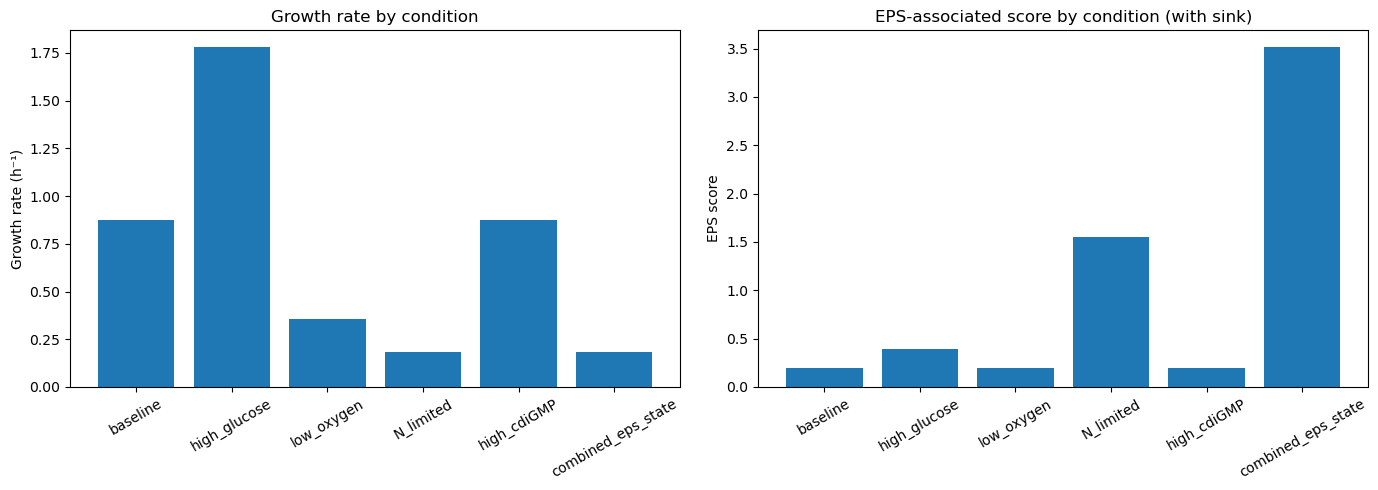

Plot saved as eps_score_with_sink.png


In [25]:
from cobra import Reaction
from cobra.io import read_sbml_model
from cobra.flux_analysis import pfba
import pandas as pd
import matplotlib.pyplot as plt

# ── reload model fresh ──────────────────────────────────────────────────────
model = read_sbml_model('iML1515.xml')

# ── add sink for udcpgl_c (fixes the UDPGPT dead-end) ───────────────────────
def add_udcpgl_sink(model):
    if "SK_udcpgl_c" not in [r.id for r in model.reactions]:
        sink = Reaction("SK_udcpgl_c")
        sink.name = "Sink for udcpgl_c (EPS polymerisation proxy)"
        sink.lower_bound = 0.0
        sink.upper_bound = 1000.0
        met = model.metabolites.get_by_id("udcpgl_c")
        sink.add_metabolites({met: -1.0})
        model.add_reactions([sink])
        print("Sink reaction SK_udcpgl_c added.")
    else:
        print("Sink already present.")

add_udcpgl_sink(model)

# ── settings ─────────────────────────────────────────────────────────────────
BIOMASS_RXN = "BIOMASS_Ec_iML1515_core_75p37M"
EPS_RXN     = "UDPGPT"
EPS_FRAC    = 0.90   # keep growth at ≥90% of max during EPS optimisation

TRACKED = [
    "UDPGPT", "PMANM", "DGUNC",
    "CDGUNPD", "LDGUNPD", "RHCCE", "AI2K"
]

# ── experimental conditions ──────────────────────────────────────────────────
base_medium = model.medium.copy()

conditions = {
    "baseline":           {"medium_changes": {},                                          "knockouts": []},
    "high_glucose":       {"medium_changes": {"EX_glc__D_e": 20.0},                      "knockouts": []},
    "low_oxygen":         {"medium_changes": {"EX_o2_e":     5.0},                        "knockouts": []},
    "N_limited":          {"medium_changes": {"EX_nh4_e":    2.0},                        "knockouts": []},
    "high_cdiGMP":        {"medium_changes": {},                                          "knockouts": ["CDGUNPD", "LDGUNPD"]},
    "combined_eps_state": {"medium_changes": {"EX_glc__D_e": 20.0, "EX_nh4_e": 2.0},    "knockouts": ["CDGUNPD", "LDGUNPD"]},
}

# ── run experiment ────────────────────────────────────────────────────────────
rows = []

for cond_name, cfg in conditions.items():
    m = model.copy()

    # apply medium
    med = base_medium.copy()
    med.update(cfg["medium_changes"])
    m.medium = med

    # apply knockouts
    for rid in cfg["knockouts"]:
        rxn = m.reactions.get_by_id(rid)
        rxn.lower_bound = 0.0
        rxn.upper_bound = 0.0

    # stage 1 — normal pFBA growth
    m.objective = BIOMASS_RXN
    sol_growth = pfba(m)
    mu_max = sol_growth.fluxes[BIOMASS_RXN]

    # stage 2 — constrain growth, maximise EPS
    m.reactions.get_by_id(BIOMASS_RXN).lower_bound = EPS_FRAC * mu_max
    m.objective = EPS_RXN
    sol_eps = m.optimize()

    # collect results
    row = {"condition": cond_name, "mu_max": mu_max}
    for rid in TRACKED:
        row[f"pFBA_{rid}"]   = sol_growth.fluxes.get(rid, 0.0)
        row[f"eps_opt_{rid}"] = sol_eps.fluxes.get(rid, 0.0) if sol_eps.status == "optimal" else None

    # eps score
    row["eps_score"] = (
        3.0  * (row["eps_opt_UDPGPT"]  or 0) +
        1.5  * (row["eps_opt_PMANM"]   or 0) +
        1.0  * (row["eps_opt_DGUNC"]   or 0) +
        0.5  * (row["eps_opt_AI2K"]    or 0) +
        0.25 * (row["eps_opt_RHCCE"]   or 0) -
        1.0  * (row["eps_opt_CDGUNPD"] or 0) -
        1.0  * (row["eps_opt_LDGUNPD"] or 0)
    )

    rows.append(row)
    print(f"{cond_name}: growth={mu_max:.3f}  UDPGPT={row['eps_opt_UDPGPT']:.4f}  eps_score={row['eps_score']:.4f}")

df = pd.DataFrame(rows)
print("\n", df[["condition", "mu_max", "eps_opt_UDPGPT", "eps_score"]].to_string(index=False))

# ── plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(df["condition"], df["mu_max"])
axes[0].set_title("Growth rate by condition")
axes[0].set_ylabel("Growth rate (h⁻¹)")
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(df["condition"], df["eps_score"])
axes[1].set_title("EPS-associated score by condition (with sink)")
axes[1].set_ylabel("EPS score")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig("eps_score_with_sink.png", dpi=200)
plt.show()
print("Plot saved as eps_score_with_sink.png")


Baseline growth rate (before any modifications): 0.8770 h⁻¹
Created cellulose_c and cellulose_e metabolites
bcsA reaction formula: udpg_c --> cellulose_c + udp_c
bcsA not found in iML1515 — reaction added without gene link
Transport reaction: cellulose_c --> cellulose_e
Exchange reaction: cellulose_e --> 

Model now has 2715 total reactions
Verifying new reactions were added:
  ✓ CELSYNTH: udpg_c --> cellulose_c + udp_c
  ✓ CELLULOSEt: cellulose_c --> cellulose_e
  ✓ EX_cellulose_e: cellulose_e --> 

Sanity check — maximise EPS only (no growth constraint):
  Max EPS flux:    8.9569 mmol/gDW/h
  Biomass flux:    0.0000 h⁻¹
  CELSYNTH flux:   8.9569 mmol/gDW/h
  UDP-glucose flux:8.9569 mmol/gDW/h

Running production envelope (this takes 1-2 minutes)...

Production envelope results:
 BIOMASS_Ec_iML1515_core_75p37M  flux_minimum  flux_maximum
                       0.000000           0.0      8.956893
                       0.046158           0.0      8.490375
                       0.0923

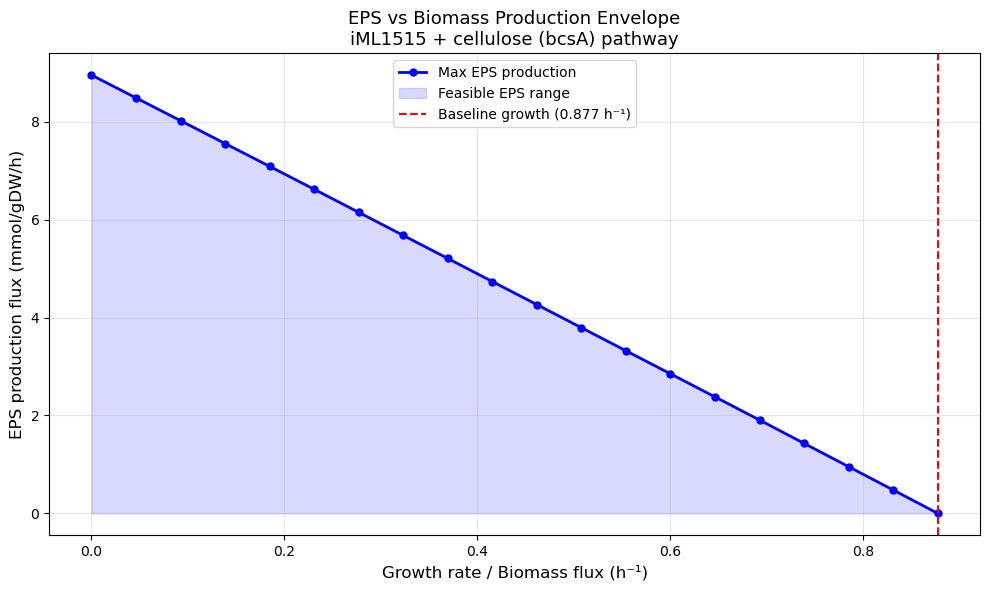

Plot saved as eps_vs_biomass_tradeoff.png


In [26]:
# ============================================================
# BUILDING AN EPS-PRODUCING E. COLI MODEL
# Steps: add bcsA reaction → transport → exchange →
#        test → production envelope → plot
# ============================================================

# --- imports ------------------------------------------------
from cobra.io import read_sbml_model          # loads the iML1515 SBML file into a cobra Model object
from cobra import Reaction, Metabolite        # classes for creating new reactions and metabolites from scratch
from cobra.flux_analysis import production_envelope  # sweeps biomass rate and measures EPS at each point
import pandas as pd                           # for handling the results table
import matplotlib.pyplot as plt              # for plotting

# ============================================================
# STEP 1: Load the model
# ============================================================

model = read_sbml_model('iML1515.xml')
# Always load fresh — avoids carrying over modifications from earlier cells

baseline_growth = model.slim_optimize()
# slim_optimize() runs FBA and returns just the objective value (growth rate)
# we store this now so we can mark it on the final plot later

print(f"Baseline growth rate (before any modifications): {baseline_growth:.4f} h⁻¹")
# Expected ~0.877 h⁻¹ — if this is 0.0 the model didn't load correctly

# ============================================================
# STEP 2: Create the cellulose metabolites
# ============================================================
# iML1515 has no cellulose metabolite — we need to create both
# an intracellular version (where bcsA makes it) and
# an extracellular version (where it ends up after secretion)

cellulose_c = Metabolite(
    id='cellulose_c',                    # '_c' suffix = cytoplasm compartment
    name='Cellulose beta-1,4-glucan',    # full descriptive name
    compartment='c',                     # 'c' = cytoplasm, where bcsA operates
    formula='C6H10O5'                    # molecular formula per glucose monomer unit (anhydroglucose)
)

cellulose_e = Metabolite(
    id='cellulose_e',                    # '_e' suffix = extracellular compartment
    name='Cellulose beta-1,4-glucan (extracellular)',
    compartment='e',                     # 'e' = outside the cell, in the medium
    formula='C6H10O5'                    # same formula — just in a different compartment
)

print("Created cellulose_c and cellulose_e metabolites")

# ============================================================
# STEP 3: Create the bcsA reaction (cellulose synthase)
# ============================================================
# bcsA is the cellulose synthase enzyme — it takes UDP-glucose
# (an activated sugar) and adds it onto the growing cellulose chain
# releasing UDP as a byproduct
#
# Real reaction: UDP-glucose → cellulose monomer + UDP
# Both UDP-glucose (udpg_c) and UDP (udp_c) already exist in iML1515
# This reaction has a REAL metabolic cost — it consumes UDP-glucose
# which the cell also needs for other things (LPS, capsule, etc.)
# That competition is what creates the genuine growth vs EPS tradeoff

bcsA_rxn = Reaction(
    id='CELSYNTH',                       # our ID for this reaction in the model
    name='Cellulose synthase (bcsA)',    # human-readable name
    subsystem='EPS Biosynthesis',        # metabolic subsystem label (for organisation)
    lower_bound=0.0,                     # 0.0 = irreversible — cellulose synthesis only goes forward
    upper_bound=1000.0                   # 1000 = effectively unconstrained in the forward direction
)

bcsA_rxn.add_metabolites({
    model.metabolites.get_by_id('udpg_c'): -1.0,  # UDP-glucose CONSUMED (negative = substrate)
    model.metabolites.get_by_id('udp_c'):   1.0,  # UDP PRODUCED (positive = product)
    cellulose_c:                            1.0   # cellulose monomer PRODUCED (our new metabolite)
})
# Note: udpg_c and udp_c already exist in iML1515 so we fetch them with get_by_id()
# cellulose_c is brand new so we reference it directly

print(f"bcsA reaction formula: {bcsA_rxn.reaction}")
# Should print: udpg_c --> cellulose_c + udp_c

# ============================================================
# STEP 4: Link bcsA gene to the reaction
# ============================================================
# Associating the gene means that if you knock out bcsA,
# this reaction gets blocked automatically — biologically correct behaviour

bcsA_gene = None
for gene in model.genes:
    if 'bcsa' in gene.name.lower() or 'bcsa' in gene.id.lower():
        bcsA_gene = gene.id
        break
# loops through all genes in the model looking for bcsA by name or ID

if bcsA_gene:
    bcsA_rxn.gene_reaction_rule = bcsA_gene   # links the reaction to the gene
    print(f"bcsA reaction linked to gene ID: {bcsA_gene}")
else:
    print("bcsA not found in iML1515 — reaction added without gene link")
    # This is okay — the reaction works, it just won't respond to gene knockouts

# ============================================================
# STEP 5: Create the cellulose transport reaction
# ============================================================
# EPS is secreted outside the cell — cellulose made in the cytoplasm
# needs to cross the membrane to get into the extracellular space
# In reality bcsC/bcsD handle this but we simplify to one step

cellulose_transport = Reaction(
    id='CELLULOSEt',
    name='Cellulose export (cytoplasm to extracellular)',
    subsystem='EPS Transport',
    lower_bound=0.0,      # irreversible — EPS only moves outward, not back in
    upper_bound=1000.0
)

cellulose_transport.add_metabolites({
    cellulose_c: -1.0,   # cellulose LEAVES cytoplasm (consumed intracellularly)
    cellulose_e:  1.0    # cellulose APPEARS extracellularly (produced outside)
})

print(f"Transport reaction: {cellulose_transport.reaction}")

# ============================================================
# STEP 6: Create the EPS exchange reaction
# ============================================================
# Exchange reactions are how FBA models represent things leaving the system entirely
# This reaction lets extracellular cellulose be "secreted into the medium"
# Crucially — the FLUX through this reaction = the EPS production rate
# This is what we measure and plot

eps_exchange = Reaction(
    id='EX_cellulose_e',
    name='Cellulose exchange (EPS secretion into medium)',
    subsystem='Exchange',
    lower_bound=0.0,      # 0 = can only secrete, cannot take up cellulose from medium
    upper_bound=1000.0
)

eps_exchange.add_metabolites({
    cellulose_e: -1.0    # cellulose leaves the model system entirely (secreted)
})

print(f"Exchange reaction: {eps_exchange.reaction}")

# ============================================================
# STEP 7: Add all three new reactions to the model
# ============================================================

model.add_reactions([bcsA_rxn, cellulose_transport, eps_exchange])
# add_reactions() takes a list — adds all three in one call

print(f"\nModel now has {len(model.reactions)} total reactions")
print("Verifying new reactions were added:")
for rxn_id in ['CELSYNTH', 'CELLULOSEt', 'EX_cellulose_e']:
    rxn = model.reactions.get_by_id(rxn_id)
    print(f"  ✓ {rxn_id}: {rxn.reaction}")

# ============================================================
# STEP 8: Quick sanity check — can EPS actually flow now?
# ============================================================
# Before running the full analysis, verify the pathway is connected end-to-end
# by asking: what is the maximum EPS the model can produce if we only care about EPS?

with model:
    # 'with model:' creates a temporary context — any changes inside are reverted after
    # this means this test won't affect the model state for the analysis below

    model.objective = 'EX_cellulose_e'   # set objective to maximise EPS secretion
    sol = model.optimize()

    print(f"\nSanity check — maximise EPS only (no growth constraint):")
    print(f"  Max EPS flux:    {sol.fluxes['EX_cellulose_e']:.4f} mmol/gDW/h")
    print(f"  Biomass flux:    {sol.fluxes['BIOMASS_Ec_iML1515_core_75p37M']:.4f} h⁻¹")
    print(f"  CELSYNTH flux:   {sol.fluxes['CELSYNTH']:.4f} mmol/gDW/h")
    print(f"  UDP-glucose flux:{sol.fluxes['GALUi']:.4f} mmol/gDW/h")
    # GALUi is the reaction that makes UDP-glucose — should be active if EPS is running

# If EPS flux > 0 here, the full pathway (bcsA → transport → exchange) is working

# ============================================================
# STEP 9: Production envelope — EPS vs biomass tradeoff curve
# ============================================================
# This is the core analysis for studying EPS vs biomass
#
# How it works:
# 1. Takes the biomass reaction and divides its full flux range into 20 evenly spaced points
# 2. At each biomass point, FIXES the biomass flux at that value
# 3. Then asks: what is the MINIMUM and MAXIMUM EPS the cell can produce at this growth rate?
# 4. Repeats for all 20 points
# The result is a curve showing the complete tradeoff between growth and EPS production

BIOMASS_RXN = 'BIOMASS_Ec_iML1515_core_75p37M'

print("\nRunning production envelope (this takes 1-2 minutes)...")

prod_env = production_envelope(
    model,                    # our modified model with EPS pathway added
    reactions=[BIOMASS_RXN],  # sweep over biomass flux (this becomes the x-axis)
    objective='EX_cellulose_e', # at each biomass point, optimise EPS (the y-axis)
    points=20                 # number of biomass points to evaluate (20 = good resolution)
)
# Output columns we care about:
# BIOMASS_Ec_iML1515_core_75p37M  → the fixed biomass flux at each point (x-axis)
# flux_maximum                    → max EPS achievable at that growth rate
# flux_minimum                    → min EPS achievable at that growth rate (usually 0)

print("\nProduction envelope results:")
print(prod_env[[BIOMASS_RXN, 'flux_minimum', 'flux_maximum']].to_string(index=False))

prod_env.to_csv('eps_biomass_production_envelope.csv', index=False)
print("\nSaved full results to: eps_biomass_production_envelope.csv")

# ============================================================
# STEP 10: Plot the EPS vs biomass tradeoff curve
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

# Main line — maximum EPS achievable at each growth rate
ax.plot(
    prod_env[BIOMASS_RXN],         # x-axis: growth rate (h⁻¹)
    prod_env['flux_maximum'],      # y-axis: maximum EPS production (mmol/gDW/h)
    'b-o',                         # blue line with circle markers
    linewidth=2,
    markersize=5,
    label='Max EPS production'
)

# Shaded region — the feasible range between minimum and maximum EPS
# everything inside this region is theoretically achievable
ax.fill_between(
    prod_env[BIOMASS_RXN],
    prod_env['flux_minimum'],      # lower bound of shaded region
    prod_env['flux_maximum'],      # upper bound of shaded region
    alpha=0.15,                    # transparency — 0=invisible, 1=solid
    color='blue',
    label='Feasible EPS range'
)

# Vertical dashed line marking where the cell normally grows (no EPS pressure)
ax.axvline(
    x=baseline_growth,             # the growth rate we recorded at the very start
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=f'Baseline growth ({baseline_growth:.3f} h⁻¹)'
)

ax.set_xlabel('Growth rate / Biomass flux (h⁻¹)', fontsize=12)
ax.set_ylabel('EPS production flux (mmol/gDW/h)', fontsize=12)
ax.set_title('EPS vs Biomass Production Envelope\niML1515 + cellulose (bcsA) pathway', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eps_vs_biomass_tradeoff.png', dpi=200)
plt.show()
print("Plot saved as eps_vs_biomass_tradeoff.png")


Running condition: baseline...
  Max growth under baseline: 0.8770 h⁻¹
Running condition: high_glucose...
  Max growth under high_glucose: 1.7798 h⁻¹
Running condition: low_oxygen...
  Max growth under low_oxygen: 0.3535 h⁻¹
Running condition: N_limited...
  Max growth under N_limited: 0.1852 h⁻¹
Running condition: high_cdiGMP...
  Max growth under high_cdiGMP: 0.8770 h⁻¹
Running condition: combined_eps_state...
  Max growth under combined_eps_state: 0.1852 h⁻¹

All conditions complete.
Saved combined results to: eps_biomass_envelope_all_conditions.csv

Summary — max growth and max EPS per condition:
Condition              Max Growth (h⁻¹)     Max EPS (mmol/gDW/h)
-----------------------------------------------------------------
baseline               0.8770               8.9569
high_glucose           1.7798               18.1802
low_oxygen             0.3535               8.3950
N_limited              0.1852               8.9569
high_cdiGMP            0.8770               8.9569
combi

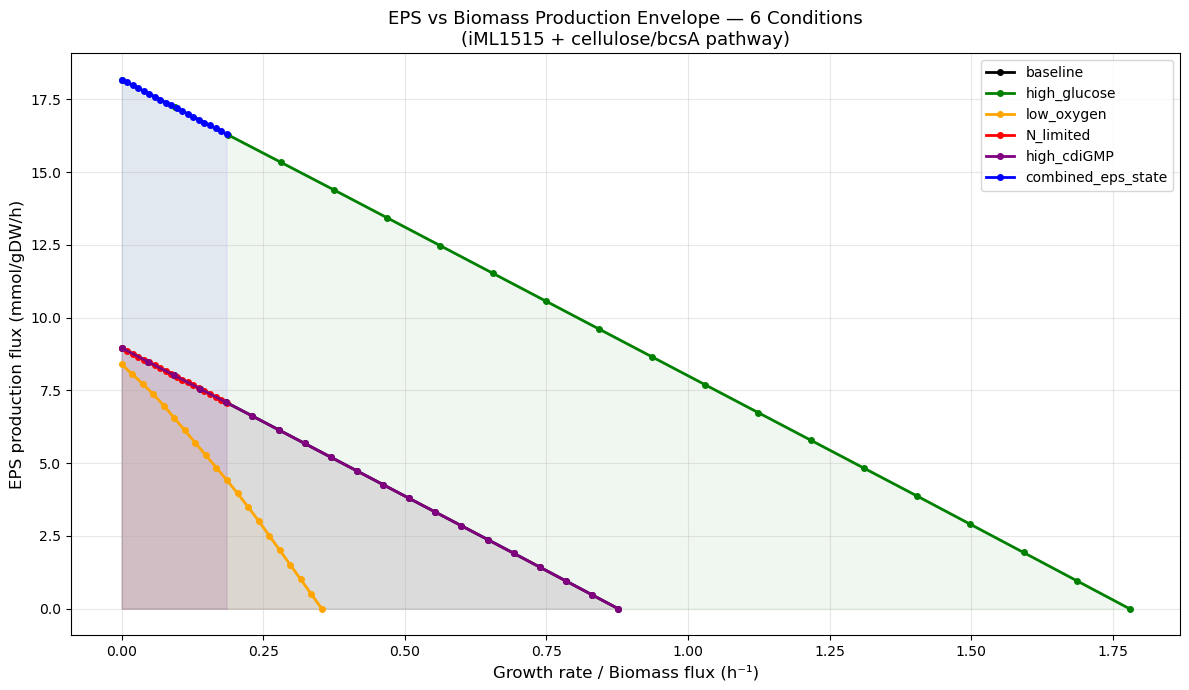

Plot saved as eps_biomass_envelope_6conditions.png


In [27]:
# ============================================================
# PRODUCTION ENVELOPE ACROSS 6 CONDITIONS
# Runs EPS vs biomass tradeoff for each environmental condition
# and overlays all curves on one plot for comparison
# ============================================================

# NOTE: Run this in the same session as the previous cell
# The model already has CELSYNTH, CELLULOSEt, EX_cellulose_e added
# We just need to apply each condition on top of it

from cobra.flux_analysis import production_envelope
import matplotlib.pyplot as plt
import pandas as pd

BIOMASS_RXN = 'BIOMASS_Ec_iML1515_core_75p37M'

# ============================================================
# STEP 1: Define the 6 conditions
# ============================================================
# Each condition is a dict with:
#   'medium_changes' — which exchange reaction bounds to update
#   'knockouts'      — which reactions to force to zero flux
#
# Medium values are uptake rates in mmol/gDW/h
# The model.medium dict stores these as positive numbers

conditions = {
    'baseline': {
        'medium_changes': {},                                        # no changes from default
        'knockouts': []
    },
    'high_glucose': {
        'medium_changes': {'EX_glc__D_e': 20.0},                   # double glucose: 10 → 20 mmol/gDW/h
        'knockouts': []
    },
    'low_oxygen': {
        'medium_changes': {'EX_o2_e': 5.0},                        # restrict oxygen: default → 5 mmol/gDW/h
        'knockouts': []
    },
    'N_limited': {
        'medium_changes': {'EX_nh4_e': 2.0},                       # restrict nitrogen: 10 → 2 mmol/gDW/h
        'knockouts': []
    },
    'high_cdiGMP': {
        'medium_changes': {},
        'knockouts': ['CDGUNPD', 'LDGUNPD']                        # knock out c-di-GMP degradation
    },
    'combined_eps_state': {
        'medium_changes': {'EX_glc__D_e': 20.0, 'EX_nh4_e': 2.0}, # high glucose + N-limited
        'knockouts': ['CDGUNPD', 'LDGUNPD']                        # + c-di-GMP locked on
    }
}

# colours for each condition on the plot
colors = {
    'baseline':           'black',
    'high_glucose':       'green',
    'low_oxygen':         'orange',
    'N_limited':          'red',
    'high_cdiGMP':        'purple',
    'combined_eps_state': 'blue'
}

# ============================================================
# STEP 2: Run production envelope for each condition
# ============================================================

all_results = {}   # stores the production envelope DataFrame for each condition

for cond_name, cfg in conditions.items():
    print(f"Running condition: {cond_name}...")

    with model:
        # 'with model:' creates a temporary context — all changes inside
        # are automatically reverted when the block ends
        # This means each condition starts from a clean copy of the base model

        # --- apply medium changes ---
        # model.medium is a dict of {exchange_rxn_id: uptake_bound}
        # We copy it, update with our changes, then reassign
        new_medium = model.medium.copy()         # start from current baseline medium
        new_medium.update(cfg['medium_changes']) # apply this condition's changes
        model.medium = new_medium                # set the updated medium on the model

        # --- apply knockouts ---
        # Setting both bounds to 0 completely blocks a reaction
        for rxn_id in cfg['knockouts']:
            rxn = model.reactions.get_by_id(rxn_id)
            rxn.lower_bound = 0.0   # cannot run in reverse
            rxn.upper_bound = 0.0   # cannot run forward either — fully blocked

        # --- quick growth check ---
        # Confirm the model is still feasible under this condition before envelope
        growth = model.slim_optimize()
        print(f"  Max growth under {cond_name}: {growth:.4f} h⁻¹")

        # --- run production envelope ---
        # reactions=[BIOMASS_RXN] → sweep biomass flux across its full range (x-axis)
        # objective='EX_cellulose_e' → at each biomass point, maximize/minimize EPS (y-axis)
        # points=20 → 20 evenly spaced biomass values from 0 to max growth
        env = production_envelope(
            model,
            reactions=[BIOMASS_RXN],
            objective='EX_cellulose_e',
            points=20
        )

        # store results with condition label
        env['condition'] = cond_name
        all_results[cond_name] = env.copy()
        # .copy() is important here — without it, the 'with' block reversion
        # could affect the stored DataFrame

print("\nAll conditions complete.")

# ============================================================
# STEP 3: Combine all results into one DataFrame and save
# ============================================================

combined_df = pd.concat(all_results.values(), ignore_index=True)
# pd.concat stacks all the individual condition DataFrames into one big table

combined_df.to_csv('eps_biomass_envelope_all_conditions.csv', index=False)
print("Saved combined results to: eps_biomass_envelope_all_conditions.csv")

# Print a summary: max EPS and max growth for each condition
print("\nSummary — max growth and max EPS per condition:")
print(f"{'Condition':<22} {'Max Growth (h⁻¹)':<20} {'Max EPS (mmol/gDW/h)'}")
print("-" * 65)
for cond_name, env in all_results.items():
    max_growth = env[BIOMASS_RXN].max()
    max_eps    = env['flux_maximum'].max()
    print(f"{cond_name:<22} {max_growth:<20.4f} {max_eps:.4f}")

# ============================================================
# STEP 4: Plot all 6 curves on one figure
# ============================================================

fig, ax = plt.subplots(figsize=(12, 7))

for cond_name, env in all_results.items():

    # plot the max EPS line for this condition
    ax.plot(
        env[BIOMASS_RXN],          # x-axis: biomass/growth rate
        env['flux_maximum'],       # y-axis: max EPS achievable at that growth rate
        '-o',
        color=colors[cond_name],   # each condition gets its own colour
        linewidth=2,
        markersize=4,
        label=cond_name
    )

    # shade the feasible region (between min and max EPS)
    ax.fill_between(
        env[BIOMASS_RXN],
        env['flux_minimum'],       # lower bound — usually 0
        env['flux_maximum'],       # upper bound
        alpha=0.06,                # very light shading so curves don't obscure each other
        color=colors[cond_name]
    )

ax.set_xlabel('Growth rate / Biomass flux (h⁻¹)', fontsize=12)
ax.set_ylabel('EPS production flux (mmol/gDW/h)', fontsize=12)
ax.set_title('EPS vs Biomass Production Envelope — 6 Conditions\n(iML1515 + cellulose/bcsA pathway)', fontsize=13)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eps_biomass_envelope_6conditions.png', dpi=200)
plt.show()
print("Plot saved as eps_biomass_envelope_6conditions.png")


## EPS Model v2 — bcsA Pathway with c-di-GMP Wiring

This section builds a proper EPS-producing E. coli model by:
1. Adding the **bcsA (cellulose synthase)** reaction with **c-di-GMP as a required cofactor**
2. Adding cellulose transport and exchange reactions so FBA can measure EPS as a real output
3. Simulating the EPS phenotype by knocking out c-di-GMP degradation (yahA / gmr)
4. Running a 6-condition analysis and computing per-cell EPS production estimates

**Why c-di-GMP matters here:** bcsA is only active when c-di-GMP is bound to it.
By making c-di-GMP a small stoichiometric input to CELSYNTH, the model is forced
to run DGUNC (ydaM) to supply c-di-GMP — connecting the regulatory signal to EPS production.
Knocking out CDGUNPD + LDGUNPD (yahA/gmr) means c-di-GMP can only exit via bcsA, 
simulating the high-c-di-GMP biofilm/EPS switch.

In [28]:
from cobra.io import read_sbml_model
from cobra import Reaction, Metabolite
from cobra.flux_analysis import pfba, production_envelope
import pandas as pd
import matplotlib.pyplot as plt

# ── Load fresh model ─────────────────────────────────────────────────────────
model = read_sbml_model('iML1515.xml')
BIOMASS_RXN = 'BIOMASS_Ec_iML1515_core_75p37M'
baseline_growth = model.slim_optimize()
print(f"Baseline growth rate: {baseline_growth:.4f} h⁻¹")

# ── New metabolites ───────────────────────────────────────────────────────────
cellulose_c = Metabolite('cellulose_c',
    name='Cellulose beta-1,4-glucan (cytoplasm)',
    compartment='c', formula='C6H10O5')

cellulose_e = Metabolite('cellulose_e',
    name='Cellulose beta-1,4-glucan (extracellular)',
    compartment='e', formula='C6H10O5')

# ── bcsA reaction: UDP-glucose + c-di-GMP cofactor → cellulose + UDP ─────────
# c-di-GMP (cdigmp_c) is already in iML1515 (made by DGUNC / ydaM).
# It activates bcsA allosterically in reality; here modelled as a small
# stoichiometric requirement (0.001 per monomer) so the model must run
# DGUNC to supply it — this connects the regulatory signal to EPS synthesis.
bcsA_rxn = Reaction('CELSYNTH',
    name='Cellulose synthase (bcsA)',
    subsystem='EPS Biosynthesis',
    lower_bound=0.0, upper_bound=1000.0)

bcsA_rxn.add_metabolites({
    model.metabolites.get_by_id('udpg_c'):    -1.000,
    model.metabolites.get_by_id('cdigmp_c'):  -0.001,
    model.metabolites.get_by_id('udp_c'):      1.000,
    cellulose_c:                               1.000,
})

# ── Transport: cytoplasm → extracellular (bcsC/D simplified to one step) ─────
transport_rxn = Reaction('CELLULOSEt',
    name='Cellulose export (cytoplasm to extracellular)',
    subsystem='EPS Transport',
    lower_bound=0.0, upper_bound=1000.0)
transport_rxn.add_metabolites({cellulose_c: -1.0, cellulose_e: 1.0})

# ── Exchange reaction: lets FBA measure EPS secreted into the medium ──────────
exchange_rxn = Reaction('EX_cellulose_e',
    name='Cellulose exchange (EPS secretion)',
    subsystem='Exchange',
    lower_bound=0.0, upper_bound=1000.0)
exchange_rxn.add_metabolites({cellulose_e: -1.0})

model.add_reactions([bcsA_rxn, transport_rxn, exchange_rxn])
print(f"\nReactions added. Model now has {len(model.reactions)} reactions.")
print(f"CELSYNTH stoichiometry: {model.reactions.get_by_id('CELSYNTH').reaction}")

# ── Sanity check ──────────────────────────────────────────────────────────────
with model:
    model.objective = 'EX_cellulose_e'
    sol = model.optimize()
    print(f"\nSanity check (maximise EPS only, no growth constraint):")
    print(f"  EPS flux (EX_cellulose_e): {sol.fluxes['EX_cellulose_e']:.4f} mmol/gDW/h")
    print(f"  CELSYNTH flux:             {sol.fluxes['CELSYNTH']:.4f} mmol/gDW/h")
    print(f"  DGUNC flux (ydaM):         {sol.fluxes['DGUNC']:.6f} mmol/gDW/h")
    print(f"  Biomass flux:              {sol.fluxes[BIOMASS_RXN]:.4f} h⁻¹")
    if sol.fluxes['EX_cellulose_e'] > 0:
        print("\n  PATHWAY IS CONNECTED ✓ — EPS can flow from udpg_c → cellulose_c → extracellular")
    else:
        print("\n  WARNING: EPS flux is zero — check pathway connectivity")

Baseline growth rate: 0.8770 h⁻¹

Reactions added. Model now has 2715 reactions.
CELSYNTH stoichiometry: 0.001 cdigmp_c + udpg_c --> cellulose_c + udp_c

Sanity check (maximise EPS only, no growth constraint):
  EPS flux (EX_cellulose_e): 8.9260 mmol/gDW/h
  CELSYNTH flux:             8.9260 mmol/gDW/h
  DGUNC flux (ydaM):         0.008926 mmol/gDW/h
  Biomass flux:              0.0000 h⁻¹

  PATHWAY IS CONNECTED ✓ — EPS can flow from udpg_c → cellulose_c → extracellular


In [29]:
# ── 6-condition EPS phenotype analysis ───────────────────────────────────────
# For each condition:
#   Stage 1 — maximise biomass (pFBA), record max growth rate
#   Stage 2 — constrain growth to 90% of max, then maximise EPS exchange flux
#
# The EPS phenotype is simulated by knocking out CDGUNPD + LDGUNPD (yahA/gmr).
# This blocks c-di-GMP degradation, so all c-di-GMP made by DGUNC (ydaM)
# must flow through CELSYNTH (bcsA) — the only remaining drain.

conditions = {
    'baseline':      {'medium_changes': {},                                        'knockouts': []},
    'high_glucose':  {'medium_changes': {'EX_glc__D_e': 20.0},                    'knockouts': []},
    'low_oxygen':    {'medium_changes': {'EX_o2_e': 5.0},                         'knockouts': []},
    'N_limited':     {'medium_changes': {'EX_nh4_e': 2.0},                        'knockouts': []},
    'EPS_phenotype': {'medium_changes': {},                                        'knockouts': ['CDGUNPD', 'LDGUNPD']},
    'combined_EPS':  {'medium_changes': {'EX_glc__D_e': 20.0, 'EX_nh4_e': 2.0}, 'knockouts': ['CDGUNPD', 'LDGUNPD']},
}

base_medium = model.medium.copy()
results = []

for cond_name, cfg in conditions.items():
    with model:
        med = base_medium.copy()
        med.update(cfg['medium_changes'])
        model.medium = med

        for rxn_id in cfg['knockouts']:
            rxn = model.reactions.get_by_id(rxn_id)
            rxn.lower_bound = 0.0
            rxn.upper_bound = 0.0

        # Stage 1: maximise biomass
        model.objective = BIOMASS_RXN
        sol_growth = pfba(model)
        mu_max = sol_growth.fluxes[BIOMASS_RXN]

        # Stage 2: constrain growth, maximise EPS
        model.reactions.get_by_id(BIOMASS_RXN).lower_bound = 0.9 * mu_max
        model.objective = 'EX_cellulose_e'
        sol_eps = model.optimize()

        eps  = sol_eps.fluxes.get('EX_cellulose_e', 0.0) if sol_eps.status == 'optimal' else 0.0
        dgunc = sol_eps.fluxes.get('DGUNC', 0.0)         if sol_eps.status == 'optimal' else 0.0

        results.append({
            'condition':              cond_name,
            'max_growth_h':           round(mu_max, 4),
            'constrained_growth_h':   round(0.9 * mu_max, 4),
            'EPS_flux_mmol_gDW_h':    round(eps, 6),
            'DGUNC_flux_mmol_gDW_h':  round(dgunc, 6),
        })
        print(f"{cond_name:<18} growth={mu_max:.3f}  EPS={eps:.4f}  DGUNC={dgunc:.6f}")

df_conditions = pd.DataFrame(results)

# ── Per-cell conversion ───────────────────────────────────────────────────────
# E. coli dry weight ≈ 280 fg/cell = 2.8e-13 g/cell
# Cellulose monomer (anhydroglucose) MW = 162.14 g/mol
DW_PER_CELL_G = 2.8e-13
CELLULOSE_MW  = 162.14

df_conditions['EPS_mmol_per_cell_per_h'] = df_conditions['EPS_flux_mmol_gDW_h'] * DW_PER_CELL_G
df_conditions['EPS_fg_per_cell_per_h']   = (df_conditions['EPS_mmol_per_cell_per_h']
                                             * CELLULOSE_MW * 1e15)

df_conditions.to_csv('eps_v2_condition_analysis.csv', index=False)
print("\n── Per-cell EPS production estimates ──────────────────────────────")
print(df_conditions[['condition','EPS_flux_mmol_gDW_h','EPS_fg_per_cell_per_h']].to_string(index=False))
print("\nSaved: eps_v2_condition_analysis.csv")

baseline           growth=0.877  EPS=0.9023  DGUNC=0.000902
high_glucose       growth=1.780  EPS=1.8311  DGUNC=0.001831
low_oxygen         growth=0.353  EPS=0.9467  DGUNC=0.000947
N_limited          growth=0.185  EPS=7.2473  DGUNC=0.007247
EPS_phenotype      growth=0.877  EPS=0.9023  DGUNC=0.000902
combined_EPS       growth=0.185  EPS=16.4389  DGUNC=0.016439

── Per-cell EPS production estimates ──────────────────────────────
    condition  EPS_flux_mmol_gDW_h  EPS_fg_per_cell_per_h
     baseline             0.902271           40962.381583
 high_glucose             1.831090           83130.021128
   low_oxygen             0.946731           42980.830015
    N_limited             7.247322          329022.620942
EPS_phenotype             0.902271           40962.381583
 combined_EPS            16.438854          746310.820517

Saved: eps_v2_condition_analysis.csv


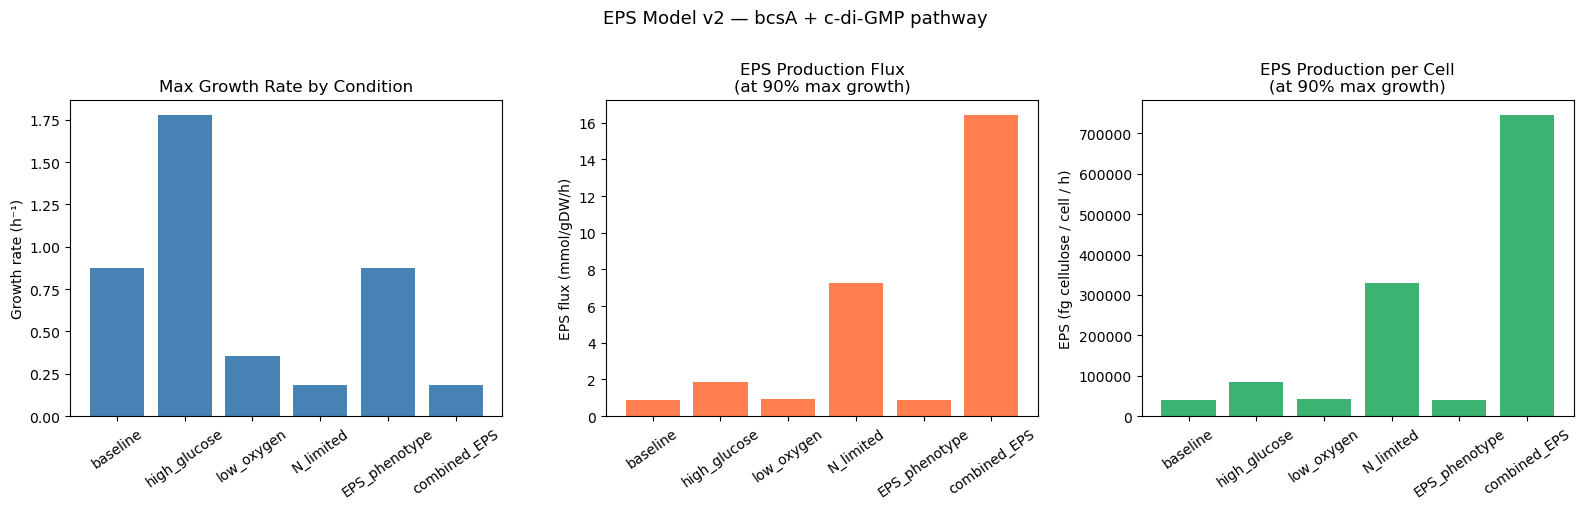

Saved: eps_v2_condition_bars.png


In [30]:
# ── Bar chart: growth rate and EPS flux per condition ────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].bar(df_conditions['condition'], df_conditions['max_growth_h'], color='steelblue')
axes[0].set_title('Max Growth Rate by Condition')
axes[0].set_ylabel('Growth rate (h⁻¹)')
axes[0].tick_params(axis='x', rotation=35)

axes[1].bar(df_conditions['condition'], df_conditions['EPS_flux_mmol_gDW_h'], color='coral')
axes[1].set_title('EPS Production Flux\n(at 90% max growth)')
axes[1].set_ylabel('EPS flux (mmol/gDW/h)')
axes[1].tick_params(axis='x', rotation=35)

axes[2].bar(df_conditions['condition'], df_conditions['EPS_fg_per_cell_per_h'], color='mediumseagreen')
axes[2].set_title('EPS Production per Cell\n(at 90% max growth)')
axes[2].set_ylabel('EPS (fg cellulose / cell / h)')
axes[2].tick_params(axis='x', rotation=35)

plt.suptitle('EPS Model v2 — bcsA + c-di-GMP pathway', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('eps_v2_condition_bars.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: eps_v2_condition_bars.png")

  baseline: done
  high_glucose: done
  N_limited: done
  EPS_phenotype: done
  combined_EPS: done


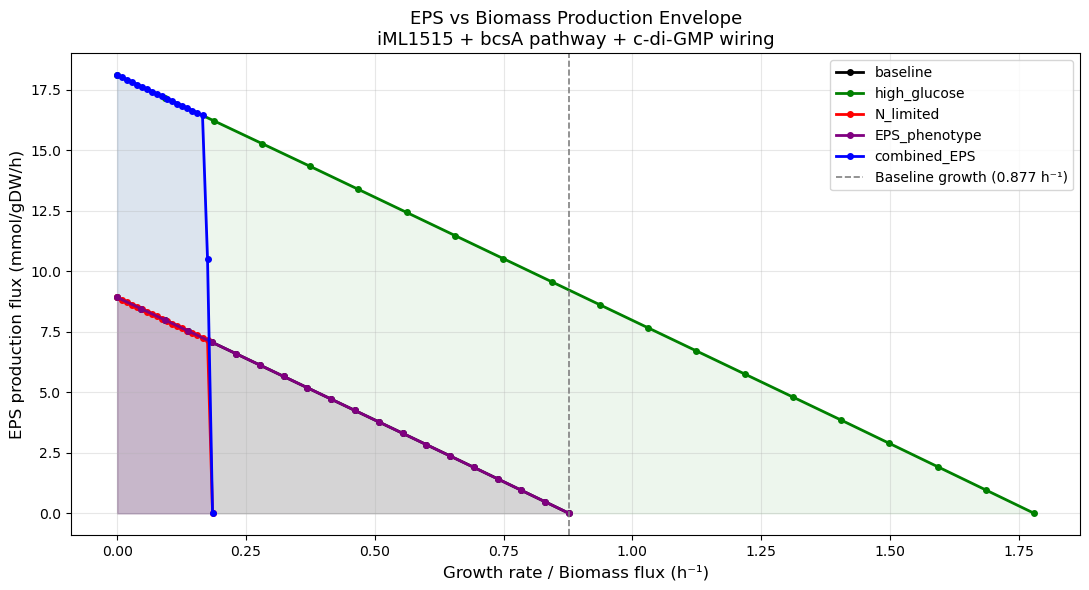

Saved: eps_v2_production_envelope.png


In [31]:
# ── Production envelope: EPS vs biomass tradeoff for key conditions ──────────
# Shows the full Pareto frontier — at each growth rate,
# what is the maximum EPS the cell can simultaneously produce?

colors = {
    'baseline':      'black',
    'high_glucose':  'green',
    'N_limited':     'red',
    'EPS_phenotype': 'purple',
    'combined_EPS':  'blue',
}

fig, ax = plt.subplots(figsize=(11, 6))

for cond_name, color in colors.items():
    cfg = conditions[cond_name]
    with model:
        med = base_medium.copy()
        med.update(cfg['medium_changes'])
        model.medium = med
        for rxn_id in cfg['knockouts']:
            rxn = model.reactions.get_by_id(rxn_id)
            rxn.lower_bound = 0.0
            rxn.upper_bound = 0.0

        env = production_envelope(
            model,
            reactions=[BIOMASS_RXN],
            objective='EX_cellulose_e',
            points=20
        )
        ax.plot(env[BIOMASS_RXN], env['flux_maximum'],
                '-o', color=color, linewidth=2, markersize=4, label=cond_name)
        ax.fill_between(env[BIOMASS_RXN], env['flux_minimum'], env['flux_maximum'],
                        alpha=0.07, color=color)
    print(f"  {cond_name}: done")

ax.axvline(x=baseline_growth, color='gray', linestyle='--', linewidth=1.2,
           label=f'Baseline growth ({baseline_growth:.3f} h⁻¹)')
ax.set_xlabel('Growth rate / Biomass flux (h⁻¹)', fontsize=12)
ax.set_ylabel('EPS production flux (mmol/gDW/h)', fontsize=12)
ax.set_title('EPS vs Biomass Production Envelope\niML1515 + bcsA pathway + c-di-GMP wiring', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('eps_v2_production_envelope.png', dpi=200)
plt.show()
print("Saved: eps_v2_production_envelope.png")

## EPS Model v3 — All Three Pathways: Cellulose + Colanic Acid (Wca) + PNAG

**E. coli makes three distinct EPS types.** This section adds all of them.

| Pathway | Key gene | EPS product | What was added |
|---|---|---|---|
| Cellulose | bcsA | β-1,4-glucose polymer | CELSYNTH + transport + exchange (v2) |
| Colanic acid | wcaJ/Wca | Mixed sugar polymer | COLASYNTH + transport + exchange (new) |
| PNAG | pgaC (PUACGAMS) | Poly-β-1,6-GlcNAc | Exchange only — pathway mostly already in model (new) |

**Note:** PNAG decreases under N-limitation because UDP-GlcNAc (its monomer) contains nitrogen.
This emergent result is biologically realistic — the GEM correctly competes for N between growth and PNAG synthesis.

In [32]:
from cobra.io import read_sbml_model
from cobra import Reaction, Metabolite
from cobra.flux_analysis import pfba
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

model = read_sbml_model('iML1515.xml')
BIOMASS_RXN = 'BIOMASS_Ec_iML1515_core_75p37M'

# ── PATHWAY 1: Cellulose (bcsA) ── already described in v2, included here for completeness
cel_c = Metabolite('cellulose_c', compartment='c', formula='C6H10O5')
cel_e = Metabolite('cellulose_e', compartment='e', formula='C6H10O5')
r_celsynth = Reaction('CELSYNTH', lower_bound=0.0, upper_bound=1000.0)
r_celsynth.add_metabolites({model.metabolites.get_by_id('udpg_c'): -1.0,
                             model.metabolites.get_by_id('cdigmp_c'): -0.001,
                             model.metabolites.get_by_id('udp_c'): 1.0, cel_c: 1.0})
r_celt = Reaction('CELLULOSEt', lower_bound=0.0, upper_bound=1000.0)
r_celt.add_metabolites({cel_c: -1.0, cel_e: 1.0})
r_celex = Reaction('EX_cellulose_e', lower_bound=0.0, upper_bound=1000.0)
r_celex.add_metabolites({cel_e: -1.0})

# ── PATHWAY 2: Colanic acid (Wca) ─────────────────────────────────────────────
# Uses udcpgl_c (wcaJ/UDPGPT product) as the glucose starter on the undecaprenyl carrier.
# Then adds Gal, GlcA, 2× Fuc, and pyruvate (from PEP) to form one repeating unit.
# All precursors already exist in iML1515.
col_c = Metabolite('colacid_c', compartment='c', formula='C33H52O27',
                   name='Colanic acid repeating unit')
col_e = Metabolite('colacid_e', compartment='e', formula='C33H52O27',
                   name='Colanic acid (extracellular)')
r_cola = Reaction('COLASYNTH', lower_bound=0.0, upper_bound=1000.0,
                  name='Colanic acid synthase (Wca pathway)')
r_cola.add_metabolites({
    model.metabolites.get_by_id('udcpgl_c'):   -1.0,  # from wcaJ — Glc starter
    model.metabolites.get_by_id('udpgal_c'):   -1.0,  # Gal residue
    model.metabolites.get_by_id('udpglcur_c'): -1.0,  # GlcA residue
    model.metabolites.get_by_id('gdpfuc_c'):   -2.0,  # 2× Fuc residues
    model.metabolites.get_by_id('pep_c'):      -1.0,  # pyruvate modification
    col_c:                                      1.0,
    model.metabolites.get_by_id('udcpp_c'):     1.0,  # undecaprenyl-PP recycled
    model.metabolites.get_by_id('udp_c'):       2.0,
    model.metabolites.get_by_id('gdp_c'):       2.0,
    model.metabolites.get_by_id('pi_c'):        1.0,
})
r_colat = Reaction('COLAIDt', lower_bound=0.0, upper_bound=1000.0)
r_colat.add_metabolites({col_c: -1.0, col_e: 1.0})
r_colaex = Reaction('EX_colacid_e', lower_bound=0.0, upper_bound=1000.0)
r_colaex.add_metabolites({col_e: -1.0})

# ── PATHWAY 3: PNAG (pgaC/pgaB) ──────────────────────────────────────────────
# Most of this pathway ALREADY EXISTS in iML1515:
#   PUACGAMS: puacgam_c + udp_c <=> uacgam_c  (runs in reverse = synthesis)
#   PUACGAMtr: puacgam_c → puacgam_p           (cytoplasm to periplasm)
# We only need to add the extracellular export step:
pnag_e = Metabolite('puacgam_e', compartment='e', name='PNAG (extracellular)')
r_pnagex1 = Reaction('PUACGAMex', lower_bound=0.0, upper_bound=1000.0)
r_pnagex1.add_metabolites({model.metabolites.get_by_id('puacgam_p'): -1.0, pnag_e: 1.0})
r_pnagex2 = Reaction('EX_puacgam_e', lower_bound=0.0, upper_bound=1000.0)
r_pnagex2.add_metabolites({pnag_e: -1.0})

model.add_reactions([r_celsynth, r_celt, r_celex,
                     r_cola, r_colat, r_colaex,
                     r_pnagex1, r_pnagex2])

print(f"Model has {len(model.reactions)} reactions after adding all 3 EPS pathways")
print(f"CELSYNTH:  {model.reactions.get_by_id('CELSYNTH').reaction}")
print(f"COLASYNTH: {model.reactions.get_by_id('COLASYNTH').reaction}")
print(f"PUACGAMex: {model.reactions.get_by_id('PUACGAMex').reaction}")

# Sanity check all three
for rxn_id, label in [('EX_cellulose_e','Cellulose'),('EX_colacid_e','Colanic acid'),('EX_puacgam_e','PNAG')]:
    with model:
        model.objective = rxn_id
        sol = model.optimize()
        flux = sol.fluxes.get(rxn_id, 0.0)
        print(f"  Sanity check {label}: {flux:.4f} mmol/gDW/h {'✓' if flux > 0 else '✗ WARNING'}")

Model has 2720 reactions after adding all 3 EPS pathways
CELSYNTH:  0.001 cdigmp_c + udpg_c --> cellulose_c + udp_c
COLASYNTH: 2.0 gdpfuc_c + pep_c + udcpgl_c + udpgal_c + udpglcur_c --> colacid_c + 2.0 gdp_c + pi_c + udcpp_c + 2.0 udp_c
PUACGAMex: puacgam_p --> puacgam_e
  Sanity check Cellulose: 8.9260 mmol/gDW/h ✓
  Sanity check Colanic acid: 1.6618 mmol/gDW/h ✓
  Sanity check PNAG: 6.7128 mmol/gDW/h ✓


In [33]:
# ── 6-condition analysis — all three pathways simultaneously ─────────────────
# Each condition's EPS objective is set to whichever pathway gives max flux.
# We measure each pathway independently at 90% growth constraint.

conditions = {
    'baseline':      {'medium_changes': {},                                        'knockouts': []},
    'high_glucose':  {'medium_changes': {'EX_glc__D_e': 20.0},                    'knockouts': []},
    'low_oxygen':    {'medium_changes': {'EX_o2_e': 5.0},                         'knockouts': []},
    'N_limited':     {'medium_changes': {'EX_nh4_e': 2.0},                        'knockouts': []},
    'EPS_phenotype': {'medium_changes': {},                                        'knockouts': ['CDGUNPD', 'LDGUNPD']},
    'combined_EPS':  {'medium_changes': {'EX_glc__D_e': 20.0, 'EX_nh4_e': 2.0}, 'knockouts': ['CDGUNPD', 'LDGUNPD']},
}
EPS_RXNS = {'Cellulose': 'EX_cellulose_e', 'Colanic acid': 'EX_colacid_e', 'PNAG': 'EX_puacgam_e'}
DW = 2.8e-13
MW = {'Cellulose': 162.14, 'Colanic acid': 33*12+52+27*16, 'PNAG': 221.21}

base_medium = model.medium.copy()
results = []

for cond_name, cfg in conditions.items():
    with model:
        med = base_medium.copy(); med.update(cfg['medium_changes']); model.medium = med
        for rxn_id in cfg['knockouts']:
            rxn = model.reactions.get_by_id(rxn_id); rxn.lower_bound=0.0; rxn.upper_bound=0.0
        model.objective = BIOMASS_RXN
        mu_max = pfba(model).fluxes[BIOMASS_RXN]
        model.reactions.get_by_id(BIOMASS_RXN).lower_bound = 0.9 * mu_max
        row = {'condition': cond_name, 'mu_max': round(mu_max, 4)}
        for label, rxn_id in EPS_RXNS.items():
            model.objective = rxn_id
            sol = model.optimize()
            row[label] = round(sol.fluxes.get(rxn_id, 0.0), 6) if sol.status == 'optimal' else 0.0
        row['Total EPS'] = round(sum(row[k] for k in EPS_RXNS), 4)
        for label in EPS_RXNS:
            row[f'fg_{label}'] = row[label] * DW * MW[label] * 1e15
        row['fg_total'] = sum(row[f'fg_{k}'] for k in EPS_RXNS)
        results.append(row)
        print(f"{cond_name:<18} Cel={row['Cellulose']:.3f}  Wca={row['Colanic acid']:.3f}  PNAG={row['PNAG']:.3f}  Total={row['Total EPS']:.3f}")

df = pd.DataFrame(results)
df.to_csv('eps_all_pathways_analysis.csv', index=False)
print("\nSaved: eps_all_pathways_analysis.csv")
print(df[['condition','Cellulose','Colanic acid','PNAG','Total EPS','fg_total']].to_string(index=False))

baseline           Cel=0.902  Wca=0.168  PNAG=0.676  Total=1.746
high_glucose       Cel=1.831  Wca=0.340  PNAG=1.371  Total=3.543
low_oxygen         Cel=0.947  Wca=0.173  PNAG=0.625  Total=1.745
N_limited          Cel=7.247  Wca=1.347  PNAG=0.200  Total=8.794
EPS_phenotype      Cel=0.902  Wca=0.168  PNAG=0.676  Total=1.746
combined_EPS       Cel=16.439  Wca=3.057  PNAG=0.200  Total=19.696

Saved: eps_all_pathways_analysis.csv
    condition  Cellulose  Colanic acid     PNAG  Total EPS     fg_total
     baseline   0.902271      0.167727 0.675768     1.7458 1.241466e+05
 high_glucose   1.831090      0.340388 1.371420     3.5429 2.519457e+05
   low_oxygen   0.946731      0.172936 0.625231     1.7449 1.243183e+05
    N_limited   7.247322      1.346743 0.200000     8.7941 6.732479e+05
EPS_phenotype   0.902271      0.167727 0.675768     1.7458 1.241466e+05
 combined_EPS  16.438854      3.056714 0.200000    19.6956 1.511873e+06


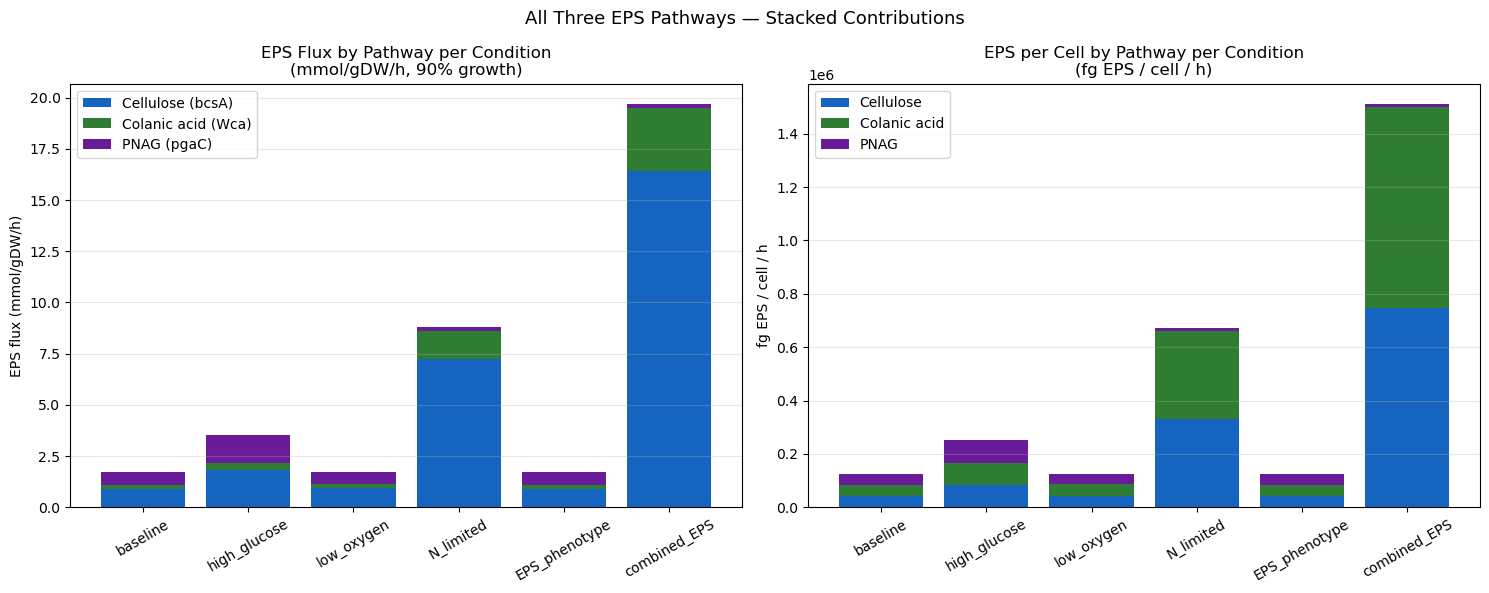

Saved: eps_stacked_contributions.png


In [34]:
# ── Stacked bar chart: pathway contributions per condition ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
conds = df['condition'].tolist()

axes[0].bar(conds, df['Cellulose'],     label='Cellulose (bcsA)',    color='#1565c0')
axes[0].bar(conds, df['Colanic acid'],  bottom=df['Cellulose'],      label='Colanic acid (Wca)', color='#2e7d32')
bot = df['Cellulose'] + df['Colanic acid']
axes[0].bar(conds, df['PNAG'],          bottom=bot,                  label='PNAG (pgaC)',        color='#6a1b9a')
axes[0].set_title('EPS Flux by Pathway per Condition\n(mmol/gDW/h, 90% growth)')
axes[0].set_ylabel('EPS flux (mmol/gDW/h)'); axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(conds, df['fg_Cellulose'],     label='Cellulose',    color='#1565c0')
axes[1].bar(conds, df['fg_Colanic acid'],  bottom=df['fg_Cellulose'], label='Colanic acid', color='#2e7d32')
bot2 = df['fg_Cellulose'] + df['fg_Colanic acid']
axes[1].bar(conds, df['fg_PNAG'],          bottom=bot2,              label='PNAG',         color='#6a1b9a')
axes[1].set_title('EPS per Cell by Pathway per Condition\n(fg EPS / cell / h)')
axes[1].set_ylabel('fg EPS / cell / h'); axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('All Three EPS Pathways — Stacked Contributions', fontsize=13)
plt.tight_layout()
plt.savefig('eps_stacked_contributions.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: eps_stacked_contributions.png")

AttributeError: 'Model' object has no attribute 'media'